# Modeling Notebook

Leak-safe temporal validation, Optuna-tuned LightGBM, validation diagnostics, and final submission export.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
np.random.seed(SEED)


def find_project_root(start: Optional[Path] = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "CLAUDE.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing CLAUDE.md.")


ROOT = find_project_root()
DATA_DIR = ROOT / "data"
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_PATH = DATA_DIR / "submission_optimized.csv"

FEATURE_CACHE_CANDIDATES = [
    DATA_DIR / "feature_cache" / "train_shift_features.parquet",
    DATA_DIR / "feature_cache" / "train_shift_features.csv",
    DATA_DIR / "train_shift_features.parquet",
    DATA_DIR / "train_shift_features.csv",
    DATA_DIR / "feature_cache" / "test_shift_features.parquet",
    DATA_DIR / "feature_cache" / "test_shift_features.csv",
    DATA_DIR / "test_shift_features.parquet",
    DATA_DIR / "test_shift_features.csv",
]

LABEL_FILES = [
    DATA_DIR / "smry_jan_train_ordered.csv",
    DATA_DIR / "smry_feb_train_ordered.csv",
    DATA_DIR / "smry_mar_train_ordered.csv",
]
FLEET_FILE = DATA_DIR / "fleet.csv"
RFID_FILE = DATA_DIR / "rfid_refuels_2026-01-01_2026-03-31.parquet"
ID_MAPPING_FILE = DATA_DIR / "id_mapping_new.csv"


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def safe_merge(left: pd.DataFrame, right: pd.DataFrame, on: Sequence[str], how: str = "left") -> pd.DataFrame:
    on = list(on)
    drop_cols = [c for c in right.columns if c not in on and c in left.columns]
    if drop_cols:
        right = right.drop(columns=drop_cols)
    return left.merge(right, on=on, how=how)


def load_first_existing(paths: Sequence[Path]) -> Optional[Path]:
    for path in paths:
        if path.exists():
            return path
    return None


def load_feature_table(kind: str) -> pd.DataFrame:
    candidates = [
        DATA_DIR / "feature_cache" / f"{kind}_shift_features.parquet",
        DATA_DIR / "feature_cache" / f"{kind}_shift_features.csv",
        DATA_DIR / f"{kind}_shift_features.parquet",
        DATA_DIR / f"{kind}_shift_features.csv",
    ]
    path = load_first_existing(candidates)
    if path is not None:
        if path.suffix == ".parquet":
            df = pd.read_parquet(path)
        else:
            df = pd.read_csv(path)
        print(f"[load] {kind}: {path.name} -> {df.shape}")
        return df

    try:
        from utils.feature_eng import build_feature_matrices

        train_df, test_df = build_feature_matrices(DATA_DIR, DATA_DIR, enable_spatial=False)
        df = train_df if kind == "train" else test_df
        print(f"[load] {kind}: rebuilt from raw telemetry -> {df.shape}")
        return df.copy()
    except Exception as exc:
        raise FileNotFoundError(
            f"Could not find cached {kind} features in data/ or rebuild them from raw telemetry."
        ) from exc


def load_labels() -> pd.DataFrame:
    frames = [pd.read_csv(path) for path in LABEL_FILES if path.exists()]
    if not frames:
        raise FileNotFoundError("No summary label files were found in data/.")

    labels = pd.concat(frames, ignore_index=True)
    labels["date"] = pd.to_datetime(labels["date"], errors="coerce").dt.normalize()
    labels["vehicle"] = labels["vehicle"].astype(str)
    labels["shift"] = labels["shift"].astype(str).str.upper()
    labels["acons"] = pd.to_numeric(labels["acons"], errors="coerce")
    labels = labels[labels["acons"].notna()].copy()
    labels = labels.drop_duplicates(["vehicle", "date", "shift"], keep="last")
    labels = labels.rename(columns={"acons": "actual_fuel"})
    labels = labels[labels["actual_fuel"] > 0].copy()
    labels = labels[["vehicle", "date", "shift", "actual_fuel"]].copy()
    print(f"[labels] Loaded {labels.shape[0]} positive target rows")
    return labels


def load_fleet_features() -> pd.DataFrame:
    if not FLEET_FILE.exists():
        return pd.DataFrame(columns=["vehicle", "fleet_type", "tankcap", "dump_switch", "has_dump_switch"])
    fleet = pd.read_csv(FLEET_FILE)
    fleet["vehicle"] = fleet["vehicle"].astype(str)
    if "tankcap" in fleet.columns:
        fleet["tankcap"] = pd.to_numeric(fleet["tankcap"], errors="coerce")
    if "dump_switch" in fleet.columns:
        fleet["dump_switch"] = pd.to_numeric(fleet["dump_switch"], errors="coerce")
    fleet["has_dump_switch"] = fleet.get("dump_switch", pd.Series(index=fleet.index, dtype=float)).notna().astype("int8")
    fleet["dump_switch"] = fleet.get("dump_switch", pd.Series(index=fleet.index, dtype=float)).fillna(0).astype(float)
    return fleet


def load_refuel_features() -> pd.DataFrame:
    if not RFID_FILE.exists():
        return pd.DataFrame(columns=["vehicle", "date", "shift_dpr", "rfid_liters", "rfid_events"])
    refuel = pd.read_parquet(RFID_FILE)
    if "fleet_type" in refuel.columns:
        refuel = refuel[refuel["fleet_type"].eq("Dumper")].copy()
    refuel["vehicle"] = refuel["vehicle"].astype(str)
    refuel["date"] = pd.to_datetime(refuel["date_dpr"], errors="coerce").dt.normalize()
    refuel["shift_dpr"] = refuel["shift_dpr"].astype(str).str.upper()
    refuel = refuel[pd.notna(refuel["date"])].copy()
    agg = refuel.groupby(["vehicle", "date", "shift_dpr"], observed=True).agg(
        rfid_liters=("litres", "sum"),
        rfid_events=("litres", "count"),
        rfid_liters_max=("litres", "max"),
    ).reset_index()
    return agg


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce").dt.normalize()
    out["day_of_week"] = out["date"].dt.dayofweek.astype("float32")
    out["day_of_month"] = out["date"].dt.day.astype("float32")
    out["week_number"] = out["date"].dt.isocalendar().week.astype("float32")
    out["month"] = out["date"].dt.month.astype("float32")
    out["is_weekend"] = (out["day_of_week"] >= 5).astype("int8")
    out["days_since_start"] = (out["date"] - out["date"].min()).dt.days.astype("float32")
    out["shift"] = out["shift"].astype(str).str.upper()
    out["shift_dpr"] = np.where(out["shift"].eq("C"), "Night", "Day")
    out["shift_is_night"] = (out["shift"].eq("C")).astype("int8")
    out["shift_enc"] = out["shift"].map({"C": 0, "A": 1, "B": 2}).astype("float32")
    return out


def add_auxiliary_features(df: pd.DataFrame, fleet: pd.DataFrame, refuels: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if not fleet.empty:
        out = safe_merge(out, fleet[[c for c in fleet.columns if c in {"vehicle", "fleet_type", "tankcap", "dump_switch", "has_dump_switch"}]], on=["vehicle"])
    if not refuels.empty:
        out = safe_merge(out, refuels, on=["vehicle", "date", "shift_dpr"], how="left")
    else:
        out["rfid_liters"] = 0.0
        out["rfid_events"] = 0.0
        out["rfid_liters_max"] = 0.0

    if "rfid_liters" in out.columns:
        out["rfid_liters"] = out["rfid_liters"].fillna(0).astype("float32")
    if "rfid_events" in out.columns:
        out["rfid_events"] = out["rfid_events"].fillna(0).astype("float32")
    if "rfid_liters_max" in out.columns:
        out["rfid_liters_max"] = out["rfid_liters_max"].fillna(0).astype("float32")
    if "tankcap" in out.columns:
        out["tankcap"] = out["tankcap"].fillna(out["tankcap"].median()).astype("float32")
    if "dump_switch" in out.columns:
        out["dump_switch"] = out["dump_switch"].fillna(0).astype("float32")
    if "has_dump_switch" in out.columns:
        out["has_dump_switch"] = out["has_dump_switch"].fillna(0).astype("int8")

    out["rfid_per_event"] = out["rfid_liters"] / (out["rfid_events"] + 1e-6)
    out["rfid_per_hour"] = out["rfid_liters"] / (out.get("ignition_on_hours", 0) + 1e-6)
    out["km_per_pings"] = out.get("shift_km", pd.Series(0, index=out.index, dtype=float)) / (out.get("n_pings", 0) + 1e-6)
    out["dump_per_km"] = out.get("dump_event_count", pd.Series(0, index=out.index, dtype=float)) / (out.get("shift_km", 0) + 1e-6)
    out["stop_per_km"] = out.get("stop_count", pd.Series(0, index=out.index, dtype=float)) / (out.get("shift_km", 0) + 1e-6)
    out["move_idle_ratio"] = out.get("moving_hours", 0) / (out.get("idle_hours", 0) + 1e-6)
    out["climb_descent_ratio"] = out.get("total_climb_m", 0) / (out.get("total_descent_m", 0) + 1.0)
    out["speed_cv"] = out.get("speed_std", 0) / (out.get("speed_mean", 0) + 1e-6)
    out["activity_density"] = out.get("n_pings", 0) / (out.get("ignition_on_hours", 0) + 1e-6)
    return out


def build_history_maps(source: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    src = source.copy()
    src = src[src["actual_fuel"].notna() & (src["actual_fuel"] > 0)].copy()
    src["day_night"] = np.where(src["shift"].eq("C"), "Night", "Day")

    global_median = float(src["actual_fuel"].median())
    vehicle_stats = src.groupby("vehicle", observed=True)["actual_fuel"].agg(
        veh_mean_fuel="mean",
        veh_std_fuel="std",
        veh_median_fuel="median",
        veh_p5_fuel=lambda s: float(np.nanpercentile(s.to_numpy(), 5)),
        veh_count="size",
    ).reset_index()

    vehicle_shift_stats = src.groupby(["vehicle", "shift"], observed=True)["actual_fuel"].agg(
        veh_shift_mean_fuel="mean",
        veh_shift_std_fuel="std",
        veh_shift_count="size",
    ).reset_index()

    vehicle_dn_stats = src.groupby(["vehicle", "day_night"], observed=True)["actual_fuel"].agg(
        veh_daynight_median_fuel="median",
        veh_daynight_mean_fuel="mean",
        veh_daynight_count="size",
    ).reset_index()

    prior = src.groupby("vehicle", observed=True)["actual_fuel"].median().reset_index(name="vehicle_prior_median")
    prior_p5 = src.groupby("vehicle", observed=True)["actual_fuel"].apply(lambda s: float(np.nanpercentile(s.to_numpy(), 5))).reset_index(name="vehicle_smart_floor")

    return {
        "global_median": global_median,
        "vehicle_stats": vehicle_stats,
        "vehicle_shift_stats": vehicle_shift_stats,
        "vehicle_dn_stats": vehicle_dn_stats,
        "vehicle_prior": prior,
        "vehicle_floor": prior_p5,
    }


def merge_history_features(df: pd.DataFrame, maps: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    out = df.copy()
    out["day_night"] = np.where(out["shift"].eq("C"), "Night", "Day")
    out = safe_merge(out, maps["vehicle_stats"], on=["vehicle"])
    out = safe_merge(out, maps["vehicle_shift_stats"], on=["vehicle", "shift"])
    out = safe_merge(out, maps["vehicle_dn_stats"], on=["vehicle", "day_night"])
    out = safe_merge(out, maps["vehicle_prior"], on=["vehicle"])
    out = safe_merge(out, maps["vehicle_floor"], on=["vehicle"])

    out["veh_mean_fuel"] = out["veh_mean_fuel"].fillna(maps["global_median"])
    out["veh_std_fuel"] = out["veh_std_fuel"].fillna(0)
    out["veh_median_fuel"] = out["veh_median_fuel"].fillna(maps["global_median"])
    out["veh_p5_fuel"] = out["veh_p5_fuel"].fillna(max(maps["global_median"] * 0.25, 10.0))
    out["veh_count"] = out["veh_count"].fillna(0)
    out["veh_shift_mean_fuel"] = out["veh_shift_mean_fuel"].fillna(out["veh_median_fuel"])
    out["veh_shift_std_fuel"] = out["veh_shift_std_fuel"].fillna(0)
    out["veh_shift_count"] = out["veh_shift_count"].fillna(0)
    out["veh_daynight_median_fuel"] = out["veh_daynight_median_fuel"].fillna(out["veh_median_fuel"])
    out["veh_daynight_mean_fuel"] = out["veh_daynight_mean_fuel"].fillna(out["veh_mean_fuel"])
    out["veh_daynight_count"] = out["veh_daynight_count"].fillna(0)
    out["vehicle_prior_median"] = out["vehicle_prior_median"].fillna(out["veh_median_fuel"])
    out["vehicle_smart_floor"] = out["vehicle_smart_floor"].fillna(10.0)
    out["prior_pred"] = out["veh_daynight_median_fuel"].where(out["veh_daynight_median_fuel"].notna(), out["vehicle_prior_median"])
    out["prior_pred"] = out["prior_pred"].fillna(maps["global_median"])
    out["smart_floor"] = np.maximum(out["vehicle_smart_floor"].fillna(10.0), 10.0)
    return out


def prepare_model_frames() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_base = add_calendar_features(load_feature_table("train"))
    test_base = add_calendar_features(load_feature_table("test"))
    fleet = load_fleet_features()
    refuels = load_refuel_features()
    train_base = add_auxiliary_features(train_base, fleet, refuels)
    test_base = add_auxiliary_features(test_base, fleet, refuels)

    labels = load_labels()
    train_labeled = safe_merge(train_base, labels, on=["vehicle", "date", "shift"])
    train_labeled["actual_fuel"] = train_labeled["actual_fuel"].astype("float32")
    train_labeled = train_labeled[train_labeled["actual_fuel"].notna()].copy()
    train_labeled = train_labeled[train_labeled["actual_fuel"] > 0].copy()

    train_labeled = train_labeled.sort_values(["date", "vehicle", "shift"]).reset_index(drop=True)
    test_base = test_base.sort_values(["date", "vehicle", "shift"]).reset_index(drop=True)

    train_mask = train_labeled["date"] < pd.Timestamp("2026-03-01")
    val_mask = (train_labeled["date"] >= pd.Timestamp("2026-03-01")) & (train_labeled["date"] <= pd.Timestamp("2026-03-11"))
    final_train_mask = train_labeled["date"] <= pd.Timestamp("2026-03-11")

    train_split = train_labeled.loc[train_mask].copy()
    val_split = train_labeled.loc[val_mask].copy()
    final_train_split = train_labeled.loc[final_train_mask].copy()

    train_maps = build_history_maps(train_split)
    val_frame = merge_history_features(val_split, train_maps)
    train_frame = merge_history_features(train_split, train_maps)

    full_maps = build_history_maps(final_train_split)
    final_train_frame = merge_history_features(final_train_split, full_maps)
    final_test_frame = merge_history_features(test_base, full_maps)

    return train_frame, val_frame, final_train_frame, final_test_frame, train_labeled


def align_categoricals(frames: Sequence[pd.DataFrame], cat_cols: Sequence[str]) -> None:
    for col in cat_cols:
        universe = pd.Index([])
        for frame in frames:
            if col in frame.columns:
                universe = universe.union(pd.Index(frame[col].astype(str).fillna("NA").unique()))
        dtype = pd.CategoricalDtype(categories=sorted(universe.tolist()), ordered=False)
        for frame in frames:
            if col in frame.columns:
                frame[col] = frame[col].astype(str).fillna("NA").astype(dtype)


def infer_feature_columns(train_df: pd.DataFrame, test_df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    exclude = {
        "actual_fuel",
        "acons",
        "date",
        "vehicle",
        "id",
        "day_night",
        "prior_pred",
        "smart_floor",
    }
    cat_candidates = [
        "vehicle",
        "mine_anon",
        "shift",
        "shift_dpr",
        "fleet_type",
        "day_night",
    ]
    cat_cols = [c for c in cat_candidates if c in train_df.columns and c in test_df.columns]

    feature_cols: List[str] = []
    for col in train_df.columns:
        if col in exclude or col in cat_candidates:
            continue
        if col not in test_df.columns:
            continue
        if pd.api.types.is_datetime64_any_dtype(train_df[col]):
            continue
        if train_df[col].dtype == "object" or test_df[col].dtype == "object":
            continue
        if train_df[col].nunique(dropna=True) <= 1:
            continue
        feature_cols.append(col)

    for col in cat_cols:
        if col not in feature_cols:
            feature_cols.append(col)
    return feature_cols, cat_cols


def train_lgbm_with_optuna(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_val: pd.DataFrame,
    y_val: np.ndarray,
    cat_cols: Sequence[str],
    n_trials: int = 30,
) -> Tuple[Dict[str, float], int, optuna.Study, lgb.Booster, np.ndarray]:
    dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=list(cat_cols), free_raw_data=False)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=list(cat_cols), reference=dtrain, free_raw_data=False)

    def objective(trial: optuna.Trial) -> float:
        params = {
            "objective": "regression",
            "metric": "rmse",
            "boosting_type": "gbdt",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 31, 127),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 100),
            "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 3.0),
            "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 10.0),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.65, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.65, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 0.5),
            "feature_pre_filter": False,
            "verbosity": -1,
            "seed": SEED,
            "feature_fraction_seed": SEED,
            "bagging_seed": SEED,
            "data_random_seed": SEED,
            "num_threads": -1,
        }
        model = lgb.train(
            params,
            dtrain,
            valid_sets=[dval],
            num_boost_round=5000,
            callbacks=[lgb.early_stopping(150, verbose=False)],
        )
        pred = model.predict(X_val, num_iteration=model.best_iteration)
        return rmse(y_val, pred)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "feature_pre_filter": False,
        "verbosity": -1,
        "seed": SEED,
        "feature_fraction_seed": SEED,
        "bagging_seed": SEED,
        "data_random_seed": SEED,
        "num_threads": -1,
        **study.best_params,
    }
    best_model = lgb.train(
        best_params,
        dtrain,
        valid_sets=[dval],
        num_boost_round=5000,
        callbacks=[lgb.early_stopping(150, verbose=False)],
    )
    val_pred = best_model.predict(X_val, num_iteration=best_model.best_iteration)
    return best_params, int(best_model.best_iteration), study, best_model, val_pred


def fit_final_model(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    cat_cols: Sequence[str],
    params: Dict[str, float],
    num_boost_round: int,
) -> lgb.Booster:
    dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=list(cat_cols), free_raw_data=False)
    final_params = dict(params)
    final_params.update(
        {
            "objective": "regression",
            "metric": "rmse",
            "feature_pre_filter": False,
            "verbosity": -1,
            "seed": SEED,
            "feature_fraction_seed": SEED,
            "bagging_seed": SEED,
            "data_random_seed": SEED,
            "num_threads": -1,
        }
    )
    return lgb.train(final_params, dtrain, num_boost_round=max(100, int(num_boost_round)))


def predict_with_fallback(
    model: lgb.Booster,
    df: pd.DataFrame,
    feature_cols: Sequence[str],
    fallback_cols: Sequence[str],
) -> np.ndarray:
    pred = model.predict(df[feature_cols], num_iteration=model.best_iteration if hasattr(model, "best_iteration") else None)
    pred = np.asarray(pred, dtype=float)
    fallback_mask = np.zeros(len(df), dtype=bool)
    if fallback_cols:
        fallback_mask = df[list(fallback_cols)].isna().any(axis=1).to_numpy()
    if fallback_mask.any():
        pred[fallback_mask] = df.loc[fallback_mask, "prior_pred"].to_numpy(dtype=float)
    floor = np.maximum(df["smart_floor"].to_numpy(dtype=float), 10.0)
    pred = np.maximum(pred, floor)
    return pred


def save_diagnostics(y_true: np.ndarray, y_pred: np.ndarray, model: lgb.Booster, feature_cols: Sequence[str]) -> None:
    residuals = y_true - y_pred
    feat_gain = pd.DataFrame({
        "feature": feature_cols,
        "gain": model.feature_importance(importance_type="gain")[: len(feature_cols)],
    }).sort_values("gain", ascending=False)

    top = feat_gain.head(30).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top["feature"], top["gain"], color="#1f77b4")
    ax.set_title("LightGBM Feature Importance by Gain")
    ax.set_xlabel("Gain")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / "feature_importance_gain.png", dpi=160)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_true, y_pred, s=18, alpha=0.65, color="#2c7fb8")
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    axes[0].plot([lo, hi], [lo, hi], color="black", lw=1)
    axes[0].set_title("Validation: Actual vs Predicted")
    axes[0].set_xlabel("Actual fuel")
    axes[0].set_ylabel("Predicted fuel")

    axes[1].hist(residuals, bins=40, color="#d95f0e", alpha=0.8)
    axes[1].axvline(0, color="black", lw=1)
    axes[1].set_title("Validation Residuals")
    axes[1].set_xlabel("Actual - Predicted")
    axes[1].set_ylabel("Count")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / "validation_diagnostics.png", dpi=160)
    plt.show()

    print("[feature_importance] top 20")
    print(feat_gain.head(20).to_string(index=False))


def build_submission(id_mapping: pd.DataFrame, predictions: pd.DataFrame) -> pd.DataFrame:
    sub = id_mapping.merge(predictions[["vehicle", "date", "shift", "prediction"]], on=["vehicle", "date", "shift"], how="left")
    sub = sub[["id", "prediction"]].rename(columns={"prediction": "Predicted"})
    sub["Predicted"] = sub["Predicted"].fillna(sub["Predicted"].median())
    sub = sub.sort_values("id").reset_index(drop=True)
    return sub

/home/aryannzzz/Hackathon-2/haulmark-challenge/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[load] train: train_shift_features.csv -> (4468, 21)
[load] test: test_shift_features.csv -> (2431, 21)
[labels] Loaded 3819 positive target rows
[features] 53 total | categorical=['vehicle', 'shift', 'shift_dpr', 'day_night']
[fallback] telemetry columns used: ['shift_km', 'ignition_on_hours', 'moving_hours', 'idle_hours', 'n_pings']
[optuna] best trial rmse = 49.02243
[optuna] best params = {
  "learning_rate": 0.015405146393440457,
  "num_leaves": 102,
  "max_depth": 11,
  "min_data_in_leaf": 24,
  "lambda_l1": 0.23453714365198658,
  "lambda_l2": 0.9003826971294039,
  "feature_fraction": 0.9152745972785706,
  "bagging_fraction": 0.8538745391585414,
  "bagging_freq": 5,
  "min_gain_to_split": 0.37473676246314946
}
[validation] rmse = 49.68742


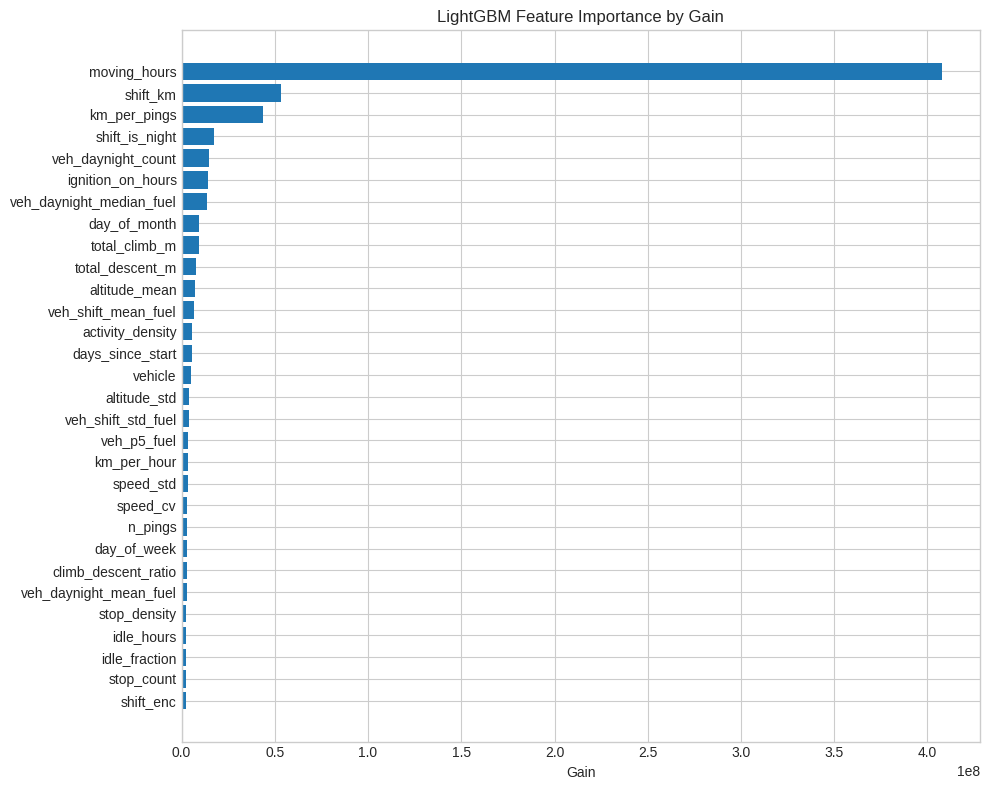

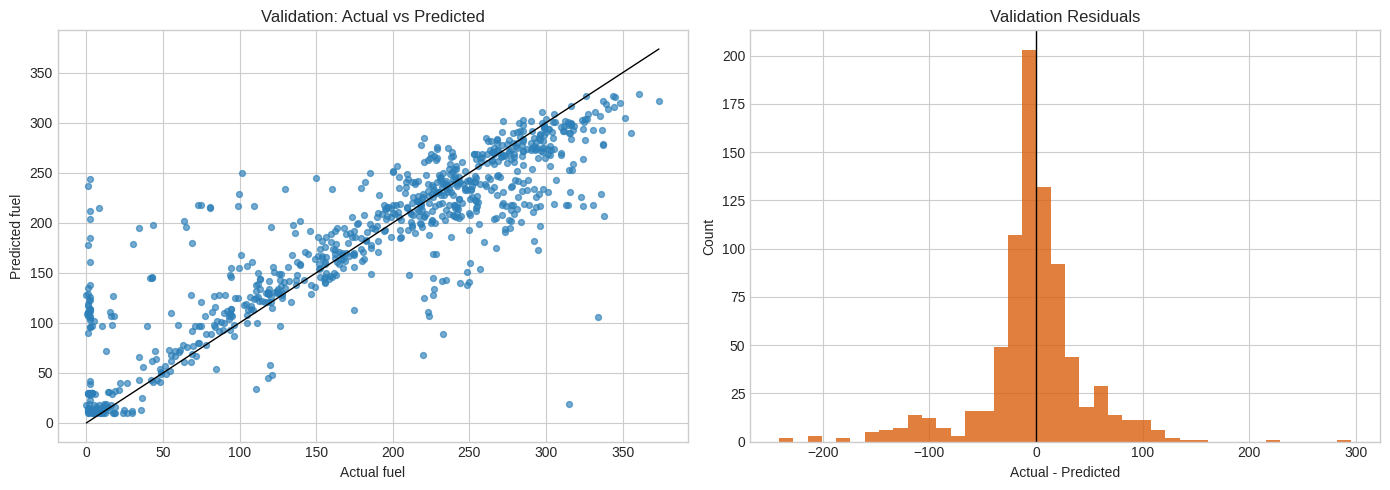

[feature_importance] top 20
                 feature         gain
            moving_hours 4.078181e+08
                shift_km 5.343312e+07
            km_per_pings 4.372845e+07
          shift_is_night 1.763167e+07
      veh_daynight_count 1.457942e+07
       ignition_on_hours 1.390864e+07
veh_daynight_median_fuel 1.359477e+07
            day_of_month 9.164852e+06
           total_climb_m 9.076679e+06
         total_descent_m 7.503795e+06
           altitude_mean 6.944871e+06
     veh_shift_mean_fuel 6.737704e+06
        activity_density 5.742688e+06
        days_since_start 5.333120e+06
                 vehicle 5.178190e+06
            altitude_std 3.987575e+06
      veh_shift_std_fuel 3.933376e+06
             veh_p5_fuel 3.650113e+06
             km_per_hour 3.610687e+06
               speed_std 3.329629e+06
[final] 53 features | categorical=['vehicle', 'shift', 'shift_dpr', 'day_night']
[submission] wrote /home/aryannzzz/Hackathon-2/haulmark-challenge/data/submission_optimized.c

In [2]:
train_frame, val_frame, final_train_frame, final_test_frame, labeled_all = prepare_model_frames()

id_mapping = pd.read_csv(ID_MAPPING_FILE)
id_mapping["date"] = pd.to_datetime(id_mapping["date"], errors="coerce").dt.normalize()
id_mapping["vehicle"] = id_mapping["vehicle"].astype(str)
id_mapping["shift"] = id_mapping["shift"].astype(str).str.upper()

feature_cols, cat_cols = infer_feature_columns(train_frame, val_frame)
print(f"[features] {len(feature_cols)} total | categorical={cat_cols}")

align_categoricals([train_frame, val_frame, final_train_frame, final_test_frame], cat_cols)

X_train = train_frame[feature_cols].copy()
y_train = train_frame["actual_fuel"].to_numpy(dtype=float)
X_val = val_frame[feature_cols].copy()
y_val = val_frame["actual_fuel"].to_numpy(dtype=float)

fallback_cols = [c for c in ["shift_km", "ignition_on_hours", "moving_hours", "idle_hours", "n_pings"] if c in final_test_frame.columns]
print(f"[fallback] telemetry columns used: {fallback_cols}")

best_params, best_iter, study, val_model, _ = train_lgbm_with_optuna(
    X_train,
    y_train,
    X_val,
    y_val,
    cat_cols,
    n_trials=30,
)

val_pred = predict_with_fallback(val_model, val_frame, feature_cols, fallback_cols)
val_score = rmse(y_val, val_pred)
print(f"[optuna] best trial rmse = {study.best_value:.5f}")
print(f"[optuna] best params = {json.dumps(study.best_params, indent=2)}")
print(f"[validation] rmse = {val_score:.5f}")

save_diagnostics(y_val, val_pred, val_model, feature_cols)

full_feature_cols, full_cat_cols = infer_feature_columns(final_train_frame, final_test_frame)
align_categoricals([final_train_frame, final_test_frame], full_cat_cols)
print(f"[final] {len(full_feature_cols)} features | categorical={full_cat_cols}")

X_full = final_train_frame[full_feature_cols].copy()
y_full = final_train_frame["actual_fuel"].to_numpy(dtype=float)
final_model = fit_final_model(X_full, y_full, full_cat_cols, best_params, best_iter)

final_test_pred = predict_with_fallback(final_model, final_test_frame, full_feature_cols, fallback_cols)
final_test_output = final_test_frame[["vehicle", "date", "shift", "prior_pred", "smart_floor"]].copy()
final_test_output["prediction"] = final_test_pred
final_test_output["prediction"] = np.maximum(final_test_output["prediction"].to_numpy(dtype=float), final_test_output["smart_floor"].to_numpy(dtype=float))

submission = build_submission(id_mapping, final_test_output[["vehicle", "date", "shift", "prediction"]])
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"[submission] wrote {SUBMISSION_PATH} -> {submission.shape}")
print(submission.head())


In [3]:
import xgboost as xgb


def prepare_xgb_matrices(train_df: pd.DataFrame, val_df: pd.DataFrame, feature_columns: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    X_tr = train_df[feature_columns].copy()
    X_va = val_df[feature_columns].copy()

    cat_like = [
        c
        for c in X_tr.columns
        if str(X_tr[c].dtype) in ("object", "category") or str(X_va[c].dtype) in ("object", "category")
    ]
    if cat_like:
        X_tr = pd.get_dummies(X_tr, columns=cat_like, dummy_na=True)
        X_va = pd.get_dummies(X_va, columns=cat_like, dummy_na=True)
        X_tr, X_va = X_tr.align(X_va, join="left", axis=1, fill_value=0.0)

    X_tr = X_tr.replace([np.inf, -np.inf], np.nan)
    X_va = X_va.replace([np.inf, -np.inf], np.nan)

    return X_tr, X_va, list(X_tr.columns)


def train_xgb_with_optuna(
    X_train_df: pd.DataFrame,
    y_train_arr: np.ndarray,
    X_val_df: pd.DataFrame,
    y_val_arr: np.ndarray,
    n_trials: int = 30,
) -> Tuple[Dict, int, optuna.Study, xgb.XGBRegressor, np.ndarray, List[str]]:
    X_tr, X_va, xgb_cols = prepare_xgb_matrices(
        pd.DataFrame(X_train_df).copy(),
        pd.DataFrame(X_val_df).copy(),
        list(X_train_df.columns),
    )

    def objective(trial: optuna.Trial) -> float:
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        }

        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=4000,
            random_state=SEED,
            tree_method="hist",
            eval_metric="rmse",
            **params,
        )

        model.fit(
            X_tr,
            y_train_arr,
            eval_set=[(X_va, y_val_arr)],
            verbose=False,
        )

        val_pred_local = model.predict(X_va)
        return rmse(y_val_arr, val_pred_local)

    study_xgb = optuna.create_study(direction="minimize")
    study_xgb.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params_xgb = study_xgb.best_params
    best_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=4000,
        random_state=SEED,
        tree_method="hist",
        eval_metric="rmse",
        **best_params_xgb,
    )
    best_model.fit(
        X_tr,
        y_train_arr,
        eval_set=[(X_va, y_val_arr)],
        verbose=False,
    )

    best_iteration = getattr(best_model, "best_iteration", None)
    if best_iteration is None:
        best_iteration = best_model.n_estimators

    val_pred_best = best_model.predict(X_va)
    return best_params_xgb, int(best_iteration), study_xgb, best_model, val_pred_best, xgb_cols


def fit_final_xgb(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_columns: List[str],
    y_full_arr: np.ndarray,
    best_params_xgb: Dict,
    best_iter_xgb: int,
) -> Tuple[xgb.XGBRegressor, pd.DataFrame, pd.DataFrame, List[str]]:
    X_tr, X_te, xgb_cols = prepare_xgb_matrices(train_df, test_df, feature_columns)

    final_model_xgb = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=max(best_iter_xgb, 50),
        random_state=SEED,
        tree_method="hist",
        eval_metric="rmse",
        **best_params_xgb,
    )
    final_model_xgb.fit(X_tr, y_full_arr, verbose=False)

    return final_model_xgb, X_tr, X_te, xgb_cols


def optimize_blend_weights(y_true: np.ndarray, pred_lgb: np.ndarray, pred_xgb: np.ndarray) -> Tuple[float, float, float]:
    best_w = 0.5
    best_rmse = np.inf
    for w in np.linspace(0.0, 1.0, 101):
        blended = (w * pred_lgb) + ((1.0 - w) * pred_xgb)
        score = rmse(y_true, blended)
        if score < best_rmse:
            best_rmse = score
            best_w = float(w)
    return best_w, float(1.0 - best_w), float(best_rmse)


def apply_xgb_fallback(raw_pred: np.ndarray, frame: pd.DataFrame, telemetry_columns: List[str]) -> np.ndarray:
    pred = np.asarray(raw_pred, dtype=float).copy()
    if telemetry_columns:
        missing_mask = frame[telemetry_columns].isna().all(axis=1).to_numpy()
        if "prior_pred" in frame.columns:
            prior_values = frame["prior_pred"].to_numpy(dtype=float)
            pred[missing_mask] = prior_values[missing_mask]
    return pred


def residual_diagnostics(val_df: pd.DataFrame, actual: np.ndarray, pred: np.ndarray) -> pd.DataFrame:
    diag = val_df.copy()
    diag["actual_fuel"] = np.asarray(actual, dtype=float)
    diag["predicted_fuel"] = np.asarray(pred, dtype=float)
    diag["abs_residual"] = np.abs(diag["actual_fuel"] - diag["predicted_fuel"])

    threshold = float(diag["abs_residual"].quantile(0.95))
    worst = diag.loc[diag["abs_residual"] >= threshold].copy()

    if "day_night" not in worst.columns:
        if "shift" in worst.columns:
            worst["day_night"] = np.where(worst["shift"].astype(str).str.upper().eq("C"), "night", "day")
        else:
            worst["day_night"] = "unknown"

    if "vehicle_id" not in worst.columns and "vehicle" in worst.columns:
        worst["vehicle_id"] = worst["vehicle"]

    mine_col = None
    for candidate in ["mine_anon", "mine", "mine_id", "mine_enc"]:
        if candidate in worst.columns:
            mine_col = candidate
            break

    print(f"[residual] top-5pct threshold(abs_error) = {threshold:.3f}")
    print(f"[residual] worst rows = {len(worst)} / {len(diag)}")

    print("\n[residual] concentration by vehicle_id (top 15)")
    if "vehicle_id" in worst.columns:
        print(worst["vehicle_id"].value_counts().head(15).to_string())
    else:
        print("vehicle_id not available")

    print("\n[residual] concentration by mine")
    if mine_col is not None:
        print(worst[mine_col].value_counts(dropna=False).to_string())
    else:
        print("mine column not available")

    print("\n[residual] concentration by day/night")
    print(worst["day_night"].value_counts(dropna=False).to_string())

    worst_export_cols = [
        c
        for c in [
            "vehicle_id",
            "vehicle",
            "date",
            "shift",
            "shift_dpr",
            "day_night",
            "mine_anon",
            "mine",
            "mine_id",
            "mine_enc",
            "actual_fuel",
            "predicted_fuel",
            "abs_residual",
            "shift_km",
            "moving_hours",
            "ignition_on_hours",
            "idle_hours",
            "n_pings",
            "prior_pred",
            "smart_floor",
        ]
        if c in worst.columns
    ]
    worst[worst_export_cols].to_csv(DATA_DIR / "worst_residuals.csv", index=False)
    print(f"[residual] wrote {DATA_DIR / 'worst_residuals.csv'}")

    return worst


# XGBoost tuning on the same temporal split (Jan-Feb train, Mar val)
xgb_best_params, xgb_best_iter, xgb_study, xgb_val_model, xgb_val_raw_pred, xgb_cols = train_xgb_with_optuna(
    X_train,
    y_train,
    X_val,
    y_val,
    n_trials=30,
)
print(f"[xgb] best trial rmse = {xgb_study.best_value:.5f}")
print(f"[xgb] best params = {json.dumps(xgb_best_params, indent=2)}")

# Apply the same missing-telemetry fallback used in LGB path
xgb_val_pred = apply_xgb_fallback(xgb_val_raw_pred, val_frame, fallback_cols)
xgb_val_rmse = rmse(y_val, xgb_val_pred)
print(f"[xgb] validation rmse = {xgb_val_rmse:.5f}")

# Optimize blend weights on validation predictions
w_lgb, w_xgb, blended_val_rmse = optimize_blend_weights(y_val, val_pred, xgb_val_pred)
val_blended_pred = (w_lgb * val_pred) + (w_xgb * xgb_val_pred)
print(f"[blend] w_lgb={w_lgb:.2f}, w_xgb={w_xgb:.2f}")
print(f"[blend] validation rmse = {blended_val_rmse:.5f}")

# Automated residual analysis on worst 5%
worst_residual_rows = residual_diagnostics(val_frame, y_val, val_blended_pred)

# Train final XGBoost on full training frame and infer on full test frame
xgb_final_model, X_xgb_full, X_xgb_test, xgb_full_cols = fit_final_xgb(
    final_train_frame,
    final_test_frame,
    full_feature_cols,
    y_full,
    xgb_best_params,
    xgb_best_iter,
)
xgb_test_raw_pred = xgb_final_model.predict(X_xgb_test)
xgb_test_pred = apply_xgb_fallback(xgb_test_raw_pred, final_test_frame, fallback_cols)

# Blend on test with optimal validation weights
blended_test_pred = (w_lgb * final_test_pred) + (w_xgb * xgb_test_pred)

# Crucial: smart floor after blend
blended_test_output = final_test_frame[["vehicle", "date", "shift", "smart_floor"]].copy()
blended_test_output["prediction"] = np.maximum(
    np.asarray(blended_test_pred, dtype=float),
    blended_test_output["smart_floor"].to_numpy(dtype=float),
)

submission_blended = build_submission(
    id_mapping,
    blended_test_output[["vehicle", "date", "shift", "prediction"]],
)
submission_blended_path = DATA_DIR / "submission_blended.csv"
submission_blended.to_csv(submission_blended_path, index=False)
print(f"[submission_blended] wrote {submission_blended_path} -> {submission_blended.shape}")
print(submission_blended.head())

[xgb] best trial rmse = 51.47065
[xgb] best params = {
  "max_depth": 10,
  "learning_rate": 0.012765908386862227,
  "subsample": 0.7304047148983066,
  "colsample_bytree": 0.6989575773046508,
  "reg_lambda": 0.013971714607753056
}
[xgb] validation rmse = 51.47065
[blend] w_lgb=0.77, w_xgb=0.23
[blend] validation rmse = 49.50397
[residual] top-5pct threshold(abs_error) = 113.087
[residual] worst rows = 41 / 815

[residual] concentration by vehicle_id (top 15)
vehicle_id
Dump043    6
Dump034    6
Dump035    4
Dump028    2
Dump024    2
Dump026    2
Dump029    2
Dump037    2
Dump038    2
Dump030    2
Dump019    1
Dump021    1
Dump018    1
Dump017    1
Dump032    1

[residual] concentration by mine
mine column not available

[residual] concentration by day/night
day_night
Night    40
Day       1
[residual] wrote /home/aryannzzz/Hackathon-2/haulmark-challenge/data/worst_residuals.csv
[submission_blended] wrote /home/aryannzzz/Hackathon-2/haulmark-challenge/data/submission_blended.csv -> (173

In [4]:
# Post-step: enforce mine001 vs mine002 diagnostics in worst residuals
fleet_for_diag = pd.read_csv(FLEET_FILE)
fleet_for_diag["vehicle"] = fleet_for_diag["vehicle"].astype(str)
mine_candidates = [c for c in ["mine_anon", "mine", "mine_id"] if c in fleet_for_diag.columns]

residual_with_mine = val_frame.copy()
if mine_candidates and "vehicle" in residual_with_mine.columns:
    mine_col_src = mine_candidates[0]
    residual_with_mine = residual_with_mine.merge(
        fleet_for_diag[["vehicle", mine_col_src]].drop_duplicates("vehicle"),
        on="vehicle",
        how="left",
    )
    if "mine_anon" not in residual_with_mine.columns:
        residual_with_mine["mine_anon"] = residual_with_mine[mine_col_src]

worst_residual_rows = residual_diagnostics(residual_with_mine, y_val, val_blended_pred)
print("[residual] refreshed mine concentration using fleet metadata")

[residual] top-5pct threshold(abs_error) = 113.087
[residual] worst rows = 41 / 815

[residual] concentration by vehicle_id (top 15)
vehicle_id
Dump043    6
Dump034    6
Dump035    4
Dump029    2
Dump030    2
Dump038    2
Dump037    2
Dump024    2
Dump026    2
Dump028    2
Dump025    1
Dump018    1
Dump027    1
Dump021    1
Dump032    1

[residual] concentration by mine
mine_anon
mine002    28
mine001    13

[residual] concentration by day/night
day_night
Night    40
Day       1
[residual] wrote /home/aryannzzz/Hackathon-2/haulmark-challenge/data/worst_residuals.csv
[residual] refreshed mine concentration using fleet metadata


In [5]:
# Quick telemetry schema probe for spatial proxy feasibility
from glob import glob
telemetry_files = sorted(glob(str(DATA_DIR / 'telemetry_*.parquet')))
print(f"[telemetry_probe] files={len(telemetry_files)}")
if telemetry_files:
    probe = pd.read_parquet(telemetry_files[0]).head(2)
    print("[telemetry_probe] sample file:", telemetry_files[0])
    print("[telemetry_probe] columns:", probe.columns.tolist())
    print(probe.head(2).to_string(index=False))

[telemetry_probe] files=8
[telemetry_probe] sample file: /home/aryannzzz/Hackathon-2/haulmark-challenge/data/telemetry_2026-01-01_2026-01-10.parquet
[telemetry_probe] columns: ['vehicle', 'ts', 'received_ts', 'latitude', 'longitude', 'altitude', 'speed', 'ignition', 'angle', 'satellites', 'gnss_pdop', 'gnss_hdop', 'gsm_signal', 'gsm_operator', 'battery_level', 'battery_current', 'battery_voltage', 'external_voltage', 'axis_x', 'axis_y', 'axis_z', 'analog_input_1', 'disthav', 'cumdist', 'fuel_volume', 'shift_dpr', 'date_dpr', 'operator_id', 'hmr_dpr', 'prod_hr_dpr', 'idle_hr_dpr', 'maint_hr_dpr', 'bd_hr_dpr', 'km_dpr', 'total_trip', 'tonnage', 'rain_loss', 'dense_fog', 'mine_anon']
vehicle                        ts               received_ts  latitude  longitude  altitude  speed  ignition  angle  satellites  gnss_pdop  gnss_hdop  gsm_signal  gsm_operator  battery_level  battery_current  battery_voltage  external_voltage  axis_x  axis_y  axis_z  analog_input_1  disthav  cumdist  fuel_volu

In [6]:
from glob import glob
from sklearn.cluster import KMeans


def assign_operational_shift(ts_series: pd.Series) -> Tuple[pd.Series, pd.Series]:
    ts_local = pd.to_datetime(ts_series, errors="coerce")
    hour = ts_local.dt.hour

    shift = np.where((hour >= 6) & (hour < 14), "A", np.where((hour >= 14) & (hour < 22), "B", "C"))
    op_date = ts_local.dt.normalize()
    op_date = np.where(hour < 6, pd.to_datetime(op_date) - pd.Timedelta(days=1), pd.to_datetime(op_date))

    return pd.Series(shift, index=ts_series.index), pd.to_datetime(pd.Series(op_date, index=ts_series.index))


def _xy_from_latlon(lat: np.ndarray, lon: np.ndarray) -> Tuple[np.ndarray, np.ndarray, float]:
    mean_lat = float(np.nanmean(lat)) if len(lat) else 0.0
    x = lon * (111320.0 * np.cos(np.deg2rad(mean_lat)))
    y = lat * 110540.0
    return x, y, mean_lat


def infer_mine002_centroids(telemetry_files: List[str], mine_value: str = "mine002", sample_per_file: int = 60000) -> Optional[np.ndarray]:
    sampled = []
    cols = ["vehicle", "ts", "latitude", "longitude", "speed", "ignition", "mine_anon"]

    for fp in telemetry_files:
        try:
            part = pd.read_parquet(fp, columns=cols)
        except Exception:
            continue

        part["mine_anon"] = part["mine_anon"].astype(str)
        stop_mask = (
            part["mine_anon"].eq(mine_value)
            & part["latitude"].notna()
            & part["longitude"].notna()
            & (part["speed"].fillna(999) < 1.0)
            & (part["ignition"].fillna(0) == 1)
        )
        sub = part.loc[stop_mask, ["latitude", "longitude"]]
        if sub.empty:
            continue
        if len(sub) > sample_per_file:
            sub = sub.sample(sample_per_file, random_state=SEED)
        sampled.append(sub)

    if not sampled:
        return None

    all_sample = pd.concat(sampled, ignore_index=True)
    lat = all_sample["latitude"].to_numpy(dtype=float)
    lon = all_sample["longitude"].to_numpy(dtype=float)
    x, y, mean_lat = _xy_from_latlon(lat, lon)

    xy = np.column_stack([x, y])
    km = KMeans(n_clusters=2, random_state=SEED, n_init=10)
    km.fit(xy)

    cent_xy = km.cluster_centers_
    cent_lon = cent_xy[:, 0] / (111320.0 * np.cos(np.deg2rad(mean_lat)))
    cent_lat = cent_xy[:, 1] / 110540.0
    centroids = np.column_stack([cent_lat, cent_lon])
    return centroids


def compute_mine002_spatial_proxy_features(keys_df: pd.DataFrame, telemetry_files: List[str], mine_value: str = "mine002") -> pd.DataFrame:
    key_cols = ["vehicle", "date", "shift"]
    keys = keys_df[key_cols].drop_duplicates().copy()
    keys["vehicle"] = keys["vehicle"].astype(str)
    keys["date"] = pd.to_datetime(keys["date"], errors="coerce").dt.normalize()
    keys["shift"] = keys["shift"].astype(str).str.upper()

    centroids = infer_mine002_centroids(telemetry_files, mine_value=mine_value)
    if centroids is None:
        out = keys.copy()
        out["avg_distance_to_rom_dump_m"] = np.nan
        out["idling_at_dumping_zone_h"] = np.nan
        return out

    c_lat = centroids[:, 0]
    c_lon = centroids[:, 1]

    cols = ["vehicle", "ts", "latitude", "longitude", "speed", "ignition", "mine_anon"]
    parts = []

    for fp in telemetry_files:
        try:
            part = pd.read_parquet(fp, columns=cols)
        except Exception:
            continue

        part["mine_anon"] = part["mine_anon"].astype(str)
        part = part.loc[part["mine_anon"].eq(mine_value)].copy()
        if part.empty:
            continue

        part["vehicle"] = part["vehicle"].astype(str)
        part["ts"] = pd.to_datetime(part["ts"], errors="coerce")
        part = part.dropna(subset=["ts", "latitude", "longitude"])
        if part.empty:
            continue

        part["shift"], part["date"] = assign_operational_shift(part["ts"])
        part["date"] = pd.to_datetime(part["date"]).dt.normalize()

        stop_mask = (part["speed"].fillna(999) < 1.0) & (part["ignition"].fillna(0) == 1)
        part = part.loc[stop_mask, ["vehicle", "ts", "date", "shift", "latitude", "longitude"]].copy()
        if part.empty:
            continue

        part = part.sort_values(["vehicle", "ts"]).reset_index(drop=True)
        part["dt_s"] = (
            part.groupby("vehicle")["ts"].shift(-1).sub(part["ts"]).dt.total_seconds().clip(lower=0, upper=300).fillna(10)
        )

        lat = part["latitude"].to_numpy(dtype=float)
        lon = part["longitude"].to_numpy(dtype=float)

        # Haversine-like local approximation in meters
        mean_lat = float(np.nanmean(np.concatenate([lat, c_lat])))
        m_per_deg_lon = 111320.0 * np.cos(np.deg2rad(mean_lat))
        m_per_deg_lat = 110540.0

        d_all = []
        for la_c, lo_c in zip(c_lat, c_lon):
            dx = (lon - lo_c) * m_per_deg_lon
            dy = (lat - la_c) * m_per_deg_lat
            d_all.append(np.sqrt((dx * dx) + (dy * dy)))
        d_stack = np.vstack(d_all)
        d_min = np.min(d_stack, axis=0)

        part["dist_min_m"] = d_min
        part["dt_h"] = part["dt_s"] / 3600.0
        part["idle_dump_h"] = np.where(part["dist_min_m"] <= 100.0, part["dt_h"], 0.0)

        agg = (
            part.groupby(["vehicle", "date", "shift"], as_index=False)
            .agg(
                dist_sum_m=("dist_min_m", "sum"),
                stop_points=("dist_min_m", "count"),
                idling_at_dumping_zone_h=("idle_dump_h", "sum"),
            )
        )
        parts.append(agg)

    if not parts:
        out = keys.copy()
        out["avg_distance_to_rom_dump_m"] = np.nan
        out["idling_at_dumping_zone_h"] = np.nan
        return out

    proxy = pd.concat(parts, ignore_index=True)
    proxy = (
        proxy.groupby(["vehicle", "date", "shift"], as_index=False)
        .agg(
            dist_sum_m=("dist_sum_m", "sum"),
            stop_points=("stop_points", "sum"),
            idling_at_dumping_zone_h=("idling_at_dumping_zone_h", "sum"),
        )
    )
    proxy["avg_distance_to_rom_dump_m"] = proxy["dist_sum_m"] / proxy["stop_points"].clip(lower=1)
    proxy = proxy[["vehicle", "date", "shift", "avg_distance_to_rom_dump_m", "idling_at_dumping_zone_h"]]

    out = keys.merge(proxy, on=["vehicle", "date", "shift"], how="left")
    return out


def enrich_specialist_features(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    full_train_df: pd.DataFrame,
    full_test_df: pd.DataFrame,
    residual_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    telemetry_files = sorted(glob(str(DATA_DIR / "telemetry_*.parquet")))

    union_keys = pd.concat(
        [
            train_df[["vehicle", "date", "shift"]],
            val_df[["vehicle", "date", "shift"]],
            full_train_df[["vehicle", "date", "shift"]],
            full_test_df[["vehicle", "date", "shift"]],
        ],
        axis=0,
        ignore_index=True,
    ).drop_duplicates()

    proxy = compute_mine002_spatial_proxy_features(union_keys, telemetry_files, mine_value="mine002")

    def _add(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out = out.merge(proxy, on=["vehicle", "date", "shift"], how="left")

        out["is_night_shift"] = np.where(out["shift"].astype(str).str.upper().eq("C"), 1, 0)
        outlier_vehicles = {"Dump043", "Dump034"}
        out["is_outlier_vehicle"] = out["vehicle"].astype(str).isin(outlier_vehicles).astype(int)

        # For non-mine002 rows, keep neutral values
        mine_col = "mine_anon" if "mine_anon" in out.columns else None
        if mine_col is not None:
            mine_mask = out[mine_col].astype(str).eq("mine002")
            out.loc[~mine_mask, "avg_distance_to_rom_dump_m"] = out.loc[~mine_mask, "avg_distance_to_rom_dump_m"].fillna(0.0)
            out.loc[~mine_mask, "idling_at_dumping_zone_h"] = out.loc[~mine_mask, "idling_at_dumping_zone_h"].fillna(0.0)

        out["avg_distance_to_rom_dump_m"] = out["avg_distance_to_rom_dump_m"].fillna(out["avg_distance_to_rom_dump_m"].median())
        out["idling_at_dumping_zone_h"] = out["idling_at_dumping_zone_h"].fillna(0.0)

        return out

    train_e = _add(train_df)
    val_e = _add(val_df)
    full_train_e = _add(full_train_df)
    full_test_e = _add(full_test_df)

    residual_e = residual_df.copy()
    if "is_night_shift" not in residual_e.columns and "shift" in residual_e.columns:
        residual_e["is_night_shift"] = np.where(residual_e["shift"].astype(str).str.upper().eq("C"), 1, 0)

    return train_e, val_e, full_train_e, full_test_e, residual_e


def train_shift_expert(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    feature_columns: List[str],
    cat_columns: List[str],
    fallback_columns: List[str],
    n_trials: int = 20,
):
    X_tr = train_df[feature_columns].copy()
    y_tr = train_df["actual_fuel"].to_numpy(dtype=float)
    X_va = val_df[feature_columns].copy()
    y_va = val_df["actual_fuel"].to_numpy(dtype=float)

    best_params_local, best_iter_local, study_local, model_local, _ = train_lgbm_with_optuna(
        X_tr,
        y_tr,
        X_va,
        y_va,
        cat_columns,
        n_trials=n_trials,
    )

    pred_val_local = predict_with_fallback(model_local, val_df, feature_columns, fallback_columns)
    rmse_local = rmse(y_va, pred_val_local)

    return {
        "best_params": best_params_local,
        "best_iter": best_iter_local,
        "study": study_local,
        "model": model_local,
        "val_pred": pred_val_local,
        "val_rmse": rmse_local,
    }


# Build specialist-ready frames
train_spec, val_spec, full_train_spec, full_test_spec, residual_base = enrich_specialist_features(
    train_frame,
    val_frame,
    final_train_frame,
    final_test_frame,
    residual_with_mine,
)

spec_feature_cols, spec_cat_cols = infer_feature_columns(train_spec, val_spec)
align_categoricals([train_spec, val_spec, full_train_spec, full_test_spec], spec_cat_cols)

print(f"[specialist] total features={len(spec_feature_cols)} | categorical={spec_cat_cols}")
print("[specialist] added features: is_night_shift, is_outlier_vehicle, avg_distance_to_rom_dump_m, idling_at_dumping_zone_h")

train_day = train_spec.loc[train_spec["is_night_shift"].eq(0)].copy()
train_night = train_spec.loc[train_spec["is_night_shift"].eq(1)].copy()
val_day = val_spec.loc[val_spec["is_night_shift"].eq(0)].copy()
val_night = val_spec.loc[val_spec["is_night_shift"].eq(1)].copy()

print(f"[specialist] train day/night = {len(train_day)}/{len(train_night)}")
print(f"[specialist] val day/night = {len(val_day)}/{len(val_night)}")

# Optuna per specialist
res_day = train_shift_expert(train_day, val_day, spec_feature_cols, spec_cat_cols, fallback_cols, n_trials=20)
res_night = train_shift_expert(train_night, val_night, spec_feature_cols, spec_cat_cols, fallback_cols, n_trials=20)

print(f"[day_expert] best trial rmse = {res_day['study'].best_value:.5f}")
print(f"[night_expert] best trial rmse = {res_night['study'].best_value:.5f}")

# Routed validation inference
val_spec_pred = np.zeros(len(val_spec), dtype=float)
mask_day_val = val_spec["is_night_shift"].eq(0).to_numpy()
mask_night_val = ~mask_day_val

val_spec_pred[mask_day_val] = predict_with_fallback(
    res_day["model"],
    val_spec.loc[mask_day_val],
    spec_feature_cols,
    fallback_cols,
)
val_spec_pred[mask_night_val] = predict_with_fallback(
    res_night["model"],
    val_spec.loc[mask_night_val],
    spec_feature_cols,
    fallback_cols,
)

specialist_val_rmse = rmse(val_spec["actual_fuel"].to_numpy(dtype=float), val_spec_pred)
print(f"[specialist] combined validation rmse = {specialist_val_rmse:.5f}")

# Train final day/night experts on full training
full_day = full_train_spec.loc[full_train_spec["is_night_shift"].eq(0)].copy()
full_night = full_train_spec.loc[full_train_spec["is_night_shift"].eq(1)].copy()

X_day = full_day[spec_feature_cols].copy()
y_day = full_day["actual_fuel"].to_numpy(dtype=float)
X_night = full_night[spec_feature_cols].copy()
y_night = full_night["actual_fuel"].to_numpy(dtype=float)

final_day_model = fit_final_model(X_day, y_day, spec_cat_cols, res_day["best_params"], res_day["best_iter"])
final_night_model = fit_final_model(X_night, y_night, spec_cat_cols, res_night["best_params"], res_night["best_iter"])

# Routed test inference
test_spec_pred = np.zeros(len(full_test_spec), dtype=float)
mask_day_test = full_test_spec["is_night_shift"].eq(0).to_numpy()
mask_night_test = ~mask_day_test

test_spec_pred[mask_day_test] = predict_with_fallback(
    final_day_model,
    full_test_spec.loc[mask_day_test],
    spec_feature_cols,
    fallback_cols,
)
test_spec_pred[mask_night_test] = predict_with_fallback(
    final_night_model,
    full_test_spec.loc[mask_night_test],
    spec_feature_cols,
    fallback_cols,
)

# Smart floor AFTER specialist routing
specialist_test_output = full_test_spec[["vehicle", "date", "shift", "smart_floor"]].copy()
specialist_test_output["prediction"] = np.maximum(
    np.asarray(test_spec_pred, dtype=float),
    specialist_test_output["smart_floor"].to_numpy(dtype=float),
)

submission_specialist = build_submission(
    id_mapping,
    specialist_test_output[["vehicle", "date", "shift", "prediction"]],
)
submission_specialist_path = DATA_DIR / "submission_specialist.csv"
submission_specialist.to_csv(submission_specialist_path, index=False)
print(f"[submission_specialist] wrote {submission_specialist_path} -> {submission_specialist.shape}")
print(submission_specialist.head())

# Updated worst-residual analysis to verify night concentration shift
worst_specialist = residual_diagnostics(residual_with_mine, val_spec["actual_fuel"].to_numpy(dtype=float), val_spec_pred)
if "day_night" in worst_specialist.columns:
    night_worst_count = int(worst_specialist["day_night"].astype(str).str.lower().eq("night").sum())
    print(f"[specialist residual] night rows in worst-5pct = {night_worst_count} / {len(worst_specialist)}")

ValueError: You are trying to merge on datetime64[ns] and datetime64[ns, Asia/Kolkata] columns for key 'date'. If you wish to proceed you should use pd.concat

In [7]:
# Timezone-safe rerun of specialist strategy

def _to_naive_normalized_date(s: pd.Series) -> pd.Series:
    d = pd.to_datetime(s, errors="coerce")
    if getattr(d.dt, "tz", None) is not None:
        d = d.dt.tz_convert(None)
    return d.dt.normalize()


def assign_operational_shift_naive(ts_series: pd.Series) -> Tuple[pd.Series, pd.Series]:
    ts_local = pd.to_datetime(ts_series, errors="coerce")
    hour = ts_local.dt.hour

    shift = np.where((hour >= 6) & (hour < 14), "A", np.where((hour >= 14) & (hour < 22), "B", "C"))
    op_date = ts_local.dt.normalize()
    op_date = np.where(hour < 6, pd.to_datetime(op_date) - pd.Timedelta(days=1), pd.to_datetime(op_date))
    op_date = pd.to_datetime(pd.Series(op_date, index=ts_series.index), errors="coerce")
    if getattr(op_date.dt, "tz", None) is not None:
        op_date = op_date.dt.tz_convert(None)
    op_date = op_date.dt.normalize()

    return pd.Series(shift, index=ts_series.index), op_date


def compute_mine002_spatial_proxy_features_safe(keys_df: pd.DataFrame, telemetry_files: List[str], mine_value: str = "mine002") -> pd.DataFrame:
    key_cols = ["vehicle", "date", "shift"]
    keys = keys_df[key_cols].drop_duplicates().copy()
    keys["vehicle"] = keys["vehicle"].astype(str)
    keys["date"] = _to_naive_normalized_date(keys["date"])
    keys["shift"] = keys["shift"].astype(str).str.upper()

    centroids = infer_mine002_centroids(telemetry_files, mine_value=mine_value)
    if centroids is None:
        out = keys.copy()
        out["avg_distance_to_rom_dump_m"] = np.nan
        out["idling_at_dumping_zone_h"] = np.nan
        return out

    c_lat = centroids[:, 0]
    c_lon = centroids[:, 1]

    cols = ["vehicle", "ts", "latitude", "longitude", "speed", "ignition", "mine_anon"]
    parts = []

    for fp in telemetry_files:
        try:
            part = pd.read_parquet(fp, columns=cols)
        except Exception:
            continue

        part["mine_anon"] = part["mine_anon"].astype(str)
        part = part.loc[part["mine_anon"].eq(mine_value)].copy()
        if part.empty:
            continue

        part["vehicle"] = part["vehicle"].astype(str)
        part["ts"] = pd.to_datetime(part["ts"], errors="coerce")
        part = part.dropna(subset=["ts", "latitude", "longitude"])
        if part.empty:
            continue

        part["shift"], part["date"] = assign_operational_shift_naive(part["ts"])

        stop_mask = (part["speed"].fillna(999) < 1.0) & (part["ignition"].fillna(0) == 1)
        part = part.loc[stop_mask, ["vehicle", "ts", "date", "shift", "latitude", "longitude"]].copy()
        if part.empty:
            continue

        part = part.sort_values(["vehicle", "ts"]).reset_index(drop=True)
        part["dt_s"] = (
            part.groupby("vehicle")["ts"].shift(-1).sub(part["ts"]).dt.total_seconds().clip(lower=0, upper=300).fillna(10)
        )

        lat = part["latitude"].to_numpy(dtype=float)
        lon = part["longitude"].to_numpy(dtype=float)

        mean_lat = float(np.nanmean(np.concatenate([lat, c_lat])))
        m_per_deg_lon = 111320.0 * np.cos(np.deg2rad(mean_lat))
        m_per_deg_lat = 110540.0

        d_all = []
        for la_c, lo_c in zip(c_lat, c_lon):
            dx = (lon - lo_c) * m_per_deg_lon
            dy = (lat - la_c) * m_per_deg_lat
            d_all.append(np.sqrt((dx * dx) + (dy * dy)))
        d_stack = np.vstack(d_all)
        d_min = np.min(d_stack, axis=0)

        part["dist_min_m"] = d_min
        part["dt_h"] = part["dt_s"] / 3600.0
        part["idle_dump_h"] = np.where(part["dist_min_m"] <= 100.0, part["dt_h"], 0.0)

        agg = (
            part.groupby(["vehicle", "date", "shift"], as_index=False)
            .agg(
                dist_sum_m=("dist_min_m", "sum"),
                stop_points=("dist_min_m", "count"),
                idling_at_dumping_zone_h=("idle_dump_h", "sum"),
            )
        )
        parts.append(agg)

    if not parts:
        out = keys.copy()
        out["avg_distance_to_rom_dump_m"] = np.nan
        out["idling_at_dumping_zone_h"] = np.nan
        return out

    proxy = pd.concat(parts, ignore_index=True)
    proxy["date"] = _to_naive_normalized_date(proxy["date"])
    proxy = (
        proxy.groupby(["vehicle", "date", "shift"], as_index=False)
        .agg(
            dist_sum_m=("dist_sum_m", "sum"),
            stop_points=("stop_points", "sum"),
            idling_at_dumping_zone_h=("idling_at_dumping_zone_h", "sum"),
        )
    )
    proxy["avg_distance_to_rom_dump_m"] = proxy["dist_sum_m"] / proxy["stop_points"].clip(lower=1)
    proxy = proxy[["vehicle", "date", "shift", "avg_distance_to_rom_dump_m", "idling_at_dumping_zone_h"]]

    return keys.merge(proxy, on=["vehicle", "date", "shift"], how="left")


telemetry_files = sorted(glob(str(DATA_DIR / "telemetry_*.parquet")))
union_keys = pd.concat(
    [
        train_frame[["vehicle", "date", "shift"]],
        val_frame[["vehicle", "date", "shift"]],
        final_train_frame[["vehicle", "date", "shift"]],
        final_test_frame[["vehicle", "date", "shift"]],
    ],
    axis=0,
    ignore_index=True,
).drop_duplicates()

proxy_safe = compute_mine002_spatial_proxy_features_safe(union_keys, telemetry_files, mine_value="mine002")


def _apply_specialist_enrichment(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["date"] = _to_naive_normalized_date(out["date"])
    out["vehicle"] = out["vehicle"].astype(str)
    out["shift"] = out["shift"].astype(str).str.upper()

    out = out.merge(proxy_safe, on=["vehicle", "date", "shift"], how="left")
    out["is_night_shift"] = np.where(out["shift"].eq("C"), 1, 0)
    out["is_outlier_vehicle"] = out["vehicle"].isin({"Dump043", "Dump034"}).astype(int)

    if "mine_anon" in out.columns:
        mine_mask = out["mine_anon"].astype(str).eq("mine002")
        out.loc[~mine_mask, "avg_distance_to_rom_dump_m"] = out.loc[~mine_mask, "avg_distance_to_rom_dump_m"].fillna(0.0)
        out.loc[~mine_mask, "idling_at_dumping_zone_h"] = out.loc[~mine_mask, "idling_at_dumping_zone_h"].fillna(0.0)

    out["avg_distance_to_rom_dump_m"] = out["avg_distance_to_rom_dump_m"].fillna(out["avg_distance_to_rom_dump_m"].median())
    out["idling_at_dumping_zone_h"] = out["idling_at_dumping_zone_h"].fillna(0.0)
    return out


train_spec = _apply_specialist_enrichment(train_frame)
val_spec = _apply_specialist_enrichment(val_frame)
full_train_spec = _apply_specialist_enrichment(final_train_frame)
full_test_spec = _apply_specialist_enrichment(final_test_frame)
residual_spec = _apply_specialist_enrichment(residual_with_mine)

spec_feature_cols, spec_cat_cols = infer_feature_columns(train_spec, val_spec)
align_categoricals([train_spec, val_spec, full_train_spec, full_test_spec], spec_cat_cols)

print(f"[specialist-safe] features={len(spec_feature_cols)} | categorical={spec_cat_cols}")

train_day = train_spec.loc[train_spec["is_night_shift"].eq(0)].copy()
train_night = train_spec.loc[train_spec["is_night_shift"].eq(1)].copy()
val_day = val_spec.loc[val_spec["is_night_shift"].eq(0)].copy()
val_night = val_spec.loc[val_spec["is_night_shift"].eq(1)].copy()

res_day = train_shift_expert(train_day, val_day, spec_feature_cols, spec_cat_cols, fallback_cols, n_trials=20)
res_night = train_shift_expert(train_night, val_night, spec_feature_cols, spec_cat_cols, fallback_cols, n_trials=20)

val_spec_pred = np.zeros(len(val_spec), dtype=float)
mask_day_val = val_spec["is_night_shift"].eq(0).to_numpy()
mask_night_val = ~mask_day_val

val_spec_pred[mask_day_val] = predict_with_fallback(res_day["model"], val_spec.loc[mask_day_val], spec_feature_cols, fallback_cols)
val_spec_pred[mask_night_val] = predict_with_fallback(res_night["model"], val_spec.loc[mask_night_val], spec_feature_cols, fallback_cols)

specialist_val_rmse = rmse(val_spec["actual_fuel"].to_numpy(dtype=float), val_spec_pred)
print(f"[specialist-safe] day best rmse={res_day['study'].best_value:.5f}")
print(f"[specialist-safe] night best rmse={res_night['study'].best_value:.5f}")
print(f"[specialist-safe] combined validation rmse={specialist_val_rmse:.5f}")

full_day = full_train_spec.loc[full_train_spec["is_night_shift"].eq(0)].copy()
full_night = full_train_spec.loc[full_train_spec["is_night_shift"].eq(1)].copy()

final_day_model = fit_final_model(
    full_day[spec_feature_cols].copy(),
    full_day["actual_fuel"].to_numpy(dtype=float),
    spec_cat_cols,
    res_day["best_params"],
    res_day["best_iter"],
)
final_night_model = fit_final_model(
    full_night[spec_feature_cols].copy(),
    full_night["actual_fuel"].to_numpy(dtype=float),
    spec_cat_cols,
    res_night["best_params"],
    res_night["best_iter"],
)

test_spec_pred = np.zeros(len(full_test_spec), dtype=float)
mask_day_test = full_test_spec["is_night_shift"].eq(0).to_numpy()
mask_night_test = ~mask_day_test

test_spec_pred[mask_day_test] = predict_with_fallback(final_day_model, full_test_spec.loc[mask_day_test], spec_feature_cols, fallback_cols)
test_spec_pred[mask_night_test] = predict_with_fallback(final_night_model, full_test_spec.loc[mask_night_test], spec_feature_cols, fallback_cols)

specialist_test_output = full_test_spec[["vehicle", "date", "shift", "smart_floor"]].copy()
specialist_test_output["prediction"] = np.maximum(
    np.asarray(test_spec_pred, dtype=float),
    specialist_test_output["smart_floor"].to_numpy(dtype=float),
)

submission_specialist = build_submission(id_mapping, specialist_test_output[["vehicle", "date", "shift", "prediction"]])
submission_specialist_path = DATA_DIR / "submission_specialist.csv"
submission_specialist.to_csv(submission_specialist_path, index=False)
print(f"[submission_specialist] wrote {submission_specialist_path} -> {submission_specialist.shape}")

worst_specialist = residual_diagnostics(residual_spec, val_spec["actual_fuel"].to_numpy(dtype=float), val_spec_pred)
if "day_night" in worst_specialist.columns:
    night_worst_count = int(worst_specialist["day_night"].astype(str).str.lower().eq("night").sum())
    print(f"[specialist-safe residual] night rows in worst-5pct = {night_worst_count} / {len(worst_specialist)}")

[specialist-safe] features=57 | categorical=['vehicle', 'shift', 'shift_dpr', 'day_night']
[specialist-safe] day best rmse=19.44565
[specialist-safe] night best rmse=84.25399
[specialist-safe] combined validation rmse=49.07179
[submission_specialist] wrote /home/aryannzzz/Hackathon-2/haulmark-challenge/data/submission_specialist.csv -> (1735, 2)
[residual] top-5pct threshold(abs_error) = 109.670
[residual] worst rows = 41 / 815

[residual] concentration by vehicle_id (top 15)
vehicle_id
Dump035    5
Dump024    4
Dump043    3
Dump034    3
Dump037    2
Dump033    2
Dump041    2
Dump027    2
Dump029    2
Dump030    2
Dump026    2
Dump038    2
Dump040    2
Dump025    1
Dump018    1

[residual] concentration by mine
mine_anon
mine002    27
mine001    14

[residual] concentration by day/night
day_night
Night    40
Day       1
[residual] wrote /home/aryannzzz/Hackathon-2/haulmark-challenge/data/worst_residuals.csv
[specialist-safe residual] night rows in worst-5pct = 40 / 41


In [8]:
import xgboost as xgb


def to_naive_date(s: pd.Series) -> pd.Series:
    d = pd.to_datetime(s, errors="coerce")
    if getattr(d.dt, "tz", None) is not None:
        d = d.dt.tz_convert(None)
    return d.dt.normalize()


def map_shift_from_ts(ts: pd.Series) -> pd.DataFrame:
    t = pd.to_datetime(ts, errors="coerce")
    hour = t.dt.hour

    shift = np.where((hour >= 6) & (hour < 14), "A", np.where((hour >= 14) & (hour < 22), "B", "C"))
    adj_date = t.dt.normalize()
    adj_date = np.where(hour < 6, pd.to_datetime(adj_date) - pd.Timedelta(days=1), pd.to_datetime(adj_date))

    out = pd.DataFrame(index=ts.index)
    out["shift"] = pd.Series(shift, index=ts.index)
    out["adj_date"] = pd.to_datetime(pd.Series(adj_date, index=ts.index), errors="coerce")
    if getattr(out["adj_date"].dt, "tz", None) is not None:
        out["adj_date"] = out["adj_date"].dt.tz_convert(None)
    out["adj_date"] = out["adj_date"].dt.normalize()
    out["shift_dpr"] = np.where(out["shift"].eq("C"), "Night", "Day")
    return out


def find_col(df: pd.DataFrame, candidates: List[str], required: bool = True) -> Optional[str]:
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    if required:
        raise KeyError(f"None of candidate columns found: {candidates}")
    return None


def build_rfid_shift_features(rfid_path: Path, key_frames: List[pd.DataFrame]) -> pd.DataFrame:
    rfid = pd.read_parquet(rfid_path)
    ts_col = find_col(rfid, ["ts", "timestamp", "event_time", "datetime", "time"])
    veh_col = find_col(rfid, ["vehicle", "vehicle_id", "veh", "asset_id"])
    fuel_col = find_col(rfid, ["fuel_added", "liters", "litres", "qty_liters", "amount", "fuel_qty"], required=False)

    rfid[veh_col] = rfid[veh_col].astype(str)
    mapped = map_shift_from_ts(rfid[ts_col])
    rfid["vehicle"] = rfid[veh_col].astype(str)
    rfid["date"] = mapped["adj_date"]
    rfid["shift"] = mapped["shift"]
    rfid["shift_dpr"] = mapped["shift_dpr"]

    if fuel_col is None:
        rfid["fuel_added_value"] = 0.0
    else:
        rfid["fuel_added_value"] = pd.to_numeric(rfid[fuel_col], errors="coerce").fillna(0.0)

    rfid_shift = (
        rfid.groupby(["vehicle", "date", "shift", "shift_dpr"], as_index=False)
        .agg(
            fuel_added_in_shift=("fuel_added_value", "sum"),
            refuel_events=("fuel_added_value", "size"),
        )
    )
    rfid_shift["is_refueled_this_shift"] = (rfid_shift["fuel_added_in_shift"] > 0).astype(int)

    keys = pd.concat(
        [kf[["vehicle", "date", "shift"]].copy() for kf in key_frames],
        axis=0,
        ignore_index=True,
    ).drop_duplicates()
    keys["vehicle"] = keys["vehicle"].astype(str)
    keys["date"] = to_naive_date(keys["date"])
    keys["shift"] = keys["shift"].astype(str).str.upper()
    keys["shift_order"] = keys["shift"].map({"C": 0, "A": 1, "B": 2}).fillna(9)

    full = keys.merge(
        rfid_shift[["vehicle", "date", "shift", "fuel_added_in_shift", "is_refueled_this_shift"]],
        on=["vehicle", "date", "shift"],
        how="left",
    )
    full["fuel_added_in_shift"] = full["fuel_added_in_shift"].fillna(0.0)
    full["is_refueled_this_shift"] = full["is_refueled_this_shift"].fillna(0).astype(int)

    full = full.sort_values(["vehicle", "date", "shift_order"]).reset_index(drop=True)
    full["refuel_date_marker"] = np.where(full["is_refueled_this_shift"].eq(1), full["date"], pd.NaT)
    full["refuel_date_marker"] = pd.to_datetime(full["refuel_date_marker"], errors="coerce")
    full["last_refuel_date"] = full.groupby("vehicle")["refuel_date_marker"].ffill()
    full["days_since_last_refuel"] = (full["date"] - full["last_refuel_date"]).dt.days
    full["days_since_last_refuel"] = full["days_since_last_refuel"].fillna(999).clip(lower=0)

    return full[["vehicle", "date", "shift", "fuel_added_in_shift", "is_refueled_this_shift", "days_since_last_refuel"]]


def add_refuel_priors(train_hist: pd.DataFrame, target_df: pd.DataFrame) -> pd.DataFrame:
    grp = (
        train_hist.groupby(["vehicle", "is_refueled_this_shift"], as_index=False)
        .agg(
            veh_refuel_mean_fuel=("actual_fuel", "mean"),
            veh_refuel_std_fuel=("actual_fuel", "std"),
            veh_refuel_count=("actual_fuel", "count"),
        )
    )
    veh_only = (
        train_hist.groupby("vehicle", as_index=False)
        .agg(
            veh_overall_mean_fuel=("actual_fuel", "mean"),
            veh_overall_std_fuel=("actual_fuel", "std"),
        )
    )

    out = target_df.merge(grp, on=["vehicle", "is_refueled_this_shift"], how="left")
    out = out.merge(veh_only, on="vehicle", how="left")

    out["veh_refuel_mean_fuel"] = out["veh_refuel_mean_fuel"].fillna(out["veh_overall_mean_fuel"])
    out["veh_refuel_std_fuel"] = out["veh_refuel_std_fuel"].fillna(out["veh_overall_std_fuel"])

    gmean = float(train_hist["actual_fuel"].mean())
    gstd = float(train_hist["actual_fuel"].std()) if len(train_hist) > 1 else 0.0

    out["veh_refuel_mean_fuel"] = out["veh_refuel_mean_fuel"].fillna(gmean)
    out["veh_refuel_std_fuel"] = out["veh_refuel_std_fuel"].fillna(gstd)
    out["veh_refuel_count"] = out["veh_refuel_count"].fillna(0)
    return out


def prepare_xgb_dense(train_df: pd.DataFrame, pred_df: pd.DataFrame, feature_columns: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    X_tr = train_df[feature_columns].copy()
    X_pr = pred_df[feature_columns].copy()

    cat_like = [c for c in X_tr.columns if str(X_tr[c].dtype) in ("object", "category") or str(X_pr[c].dtype) in ("object", "category")]
    if cat_like:
        X_tr = pd.get_dummies(X_tr, columns=cat_like, dummy_na=True)
        X_pr = pd.get_dummies(X_pr, columns=cat_like, dummy_na=True)
        X_tr, X_pr = X_tr.align(X_pr, join="left", axis=1, fill_value=0.0)

    X_tr = X_tr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_pr = X_pr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X_tr, X_pr


# -------------------------------
# RFID + Night Residual Stack Run
# -------------------------------
train_frame_h, val_frame_h, final_train_frame_h, final_test_frame_h, labeled_all_h = prepare_model_frames()

for _df in [train_frame_h, val_frame_h, final_train_frame_h, final_test_frame_h]:
    _df["vehicle"] = _df["vehicle"].astype(str)
    _df["date"] = to_naive_date(_df["date"])
    _df["shift"] = _df["shift"].astype(str).str.upper()

rfid_features = build_rfid_shift_features(
    RFID_FILE,
    [train_frame_h, val_frame_h, final_train_frame_h, final_test_frame_h],
)
print(f"[rfid] built shift features: {rfid_features.shape}")


def enrich_with_rfid(df: pd.DataFrame) -> pd.DataFrame:
    out = df.merge(rfid_features, on=["vehicle", "date", "shift"], how="left")
    out["fuel_added_in_shift"] = out["fuel_added_in_shift"].fillna(0.0)
    out["is_refueled_this_shift"] = out["is_refueled_this_shift"].fillna(0).astype(int)
    out["days_since_last_refuel"] = out["days_since_last_refuel"].fillna(999)
    out["distance_x_refuel_flag"] = out.get("shift_km", 0.0) * out["is_refueled_this_shift"]
    out["is_night_shift"] = np.where(out["shift"].eq("C"), 1, 0)
    out["is_outlier_vehicle"] = out["vehicle"].isin({"Dump043", "Dump034"}).astype(int)
    return out


train_h = enrich_with_rfid(train_frame_h)
val_h = enrich_with_rfid(val_frame_h)
train_full_h = enrich_with_rfid(final_train_frame_h)
test_full_h = enrich_with_rfid(final_test_frame_h)

# Leak-safe priors by vehicle x refuel state
val_h = add_refuel_priors(train_h[["vehicle", "is_refueled_this_shift", "actual_fuel"]].copy(), val_h)
train_h = add_refuel_priors(train_h[["vehicle", "is_refueled_this_shift", "actual_fuel"]].copy(), train_h)

train_full_h = add_refuel_priors(
    train_full_h[["vehicle", "is_refueled_this_shift", "actual_fuel"]].copy(),
    train_full_h,
)
test_full_h = add_refuel_priors(
    train_full_h[["vehicle", "is_refueled_this_shift", "actual_fuel"]].copy(),
    test_full_h,
)

feat_h, cat_h = infer_feature_columns(train_h, val_h)
align_categoricals([train_h, val_h, train_full_h, test_full_h], cat_h)
print(f"[rfid-stack] features={len(feat_h)} | categorical={cat_h}")

fallback_cols_h = [c for c in ["shift_km", "ignition_on_hours", "moving_hours", "idle_hours", "n_pings"] if c in test_full_h.columns]

# Split by shift
tr_day = train_h.loc[train_h["is_night_shift"].eq(0)].copy()
tr_night = train_h.loc[train_h["is_night_shift"].eq(1)].copy()
va_day = val_h.loc[val_h["is_night_shift"].eq(0)].copy()
va_night = val_h.loc[val_h["is_night_shift"].eq(1)].copy()

print(f"[rfid-stack] train day/night={len(tr_day)}/{len(tr_night)}")
print(f"[rfid-stack] val day/night={len(va_day)}/{len(va_night)}")

# Day expert
res_day_h = train_shift_expert(tr_day, va_day, feat_h, cat_h, fallback_cols_h, n_trials=20)

# Night expert (stage 1)
res_night_h = train_shift_expert(tr_night, va_night, feat_h, cat_h, fallback_cols_h, n_trials=20)

# Night residual learner (stage 2)
night_train_base_pred = predict_with_fallback(res_night_h["model"], tr_night, feat_h, fallback_cols_h)
night_train_residual = tr_night["actual_fuel"].to_numpy(dtype=float) - night_train_base_pred

X_night_tr_xgb, X_night_va_xgb = prepare_xgb_dense(tr_night, va_night, feat_h)
night_residual_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=25.0,
    random_state=SEED,
    tree_method="hist",
    eval_metric="rmse",
)
night_residual_xgb.fit(X_night_tr_xgb, night_train_residual, verbose=False)

# Validation routed inference
val_pred_rfid_stack = np.zeros(len(val_h), dtype=float)
mask_day_v = val_h["is_night_shift"].eq(0).to_numpy()
mask_night_v = ~mask_day_v

val_pred_day = predict_with_fallback(res_day_h["model"], val_h.loc[mask_day_v], feat_h, fallback_cols_h)
val_pred_night_base = predict_with_fallback(res_night_h["model"], val_h.loc[mask_night_v], feat_h, fallback_cols_h)
_, X_night_v_for_corr = prepare_xgb_dense(tr_night, val_h.loc[mask_night_v], feat_h)
val_pred_night_corr = night_residual_xgb.predict(X_night_v_for_corr)
val_pred_night = val_pred_night_base + val_pred_night_corr

val_pred_rfid_stack[mask_day_v] = val_pred_day
val_pred_rfid_stack[mask_night_v] = val_pred_night

val_floor = np.maximum(val_h["smart_floor"].to_numpy(dtype=float), 10.0)
val_pred_rfid_stack = np.maximum(val_pred_rfid_stack, val_floor)

# Metrics
y_val_h = val_h["actual_fuel"].to_numpy(dtype=float)
day_rmse = rmse(va_day["actual_fuel"].to_numpy(dtype=float), val_pred_day)
night_true = va_night["actual_fuel"].to_numpy(dtype=float)
night_rmse = rmse(night_true, val_pred_rfid_stack[mask_night_v])
combined_rmse = rmse(y_val_h, val_pred_rfid_stack)

print(f"[rfid-stack] day rmse = {day_rmse:.5f}")
print(f"[rfid-stack] night rmse (after correction) = {night_rmse:.5f}")
print(f"[rfid-stack] combined rmse = {combined_rmse:.5f}")

# Final models on full train data
full_day_h = train_full_h.loc[train_full_h["is_night_shift"].eq(0)].copy()
full_night_h = train_full_h.loc[train_full_h["is_night_shift"].eq(1)].copy()

final_day_h = fit_final_model(
    full_day_h[feat_h].copy(),
    full_day_h["actual_fuel"].to_numpy(dtype=float),
    cat_h,
    res_day_h["best_params"],
    res_day_h["best_iter"],
)
final_night_h = fit_final_model(
    full_night_h[feat_h].copy(),
    full_night_h["actual_fuel"].to_numpy(dtype=float),
    cat_h,
    res_night_h["best_params"],
    res_night_h["best_iter"],
)

full_night_base_pred = predict_with_fallback(final_night_h, full_night_h, feat_h, fallback_cols_h)
full_night_residual = full_night_h["actual_fuel"].to_numpy(dtype=float) - full_night_base_pred

X_night_full_xgb, X_night_test_xgb = prepare_xgb_dense(full_night_h, test_full_h.loc[test_full_h["is_night_shift"].eq(1)], feat_h)
final_night_residual_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=25.0,
    random_state=SEED,
    tree_method="hist",
    eval_metric="rmse",
)
final_night_residual_xgb.fit(X_night_full_xgb, full_night_residual, verbose=False)

# Routed test predictions
test_pred_rfid_stack = np.zeros(len(test_full_h), dtype=float)
mask_day_t = test_full_h["is_night_shift"].eq(0).to_numpy()
mask_night_t = ~mask_day_t

test_pred_day = predict_with_fallback(final_day_h, test_full_h.loc[mask_day_t], feat_h, fallback_cols_h)
test_pred_night_base = predict_with_fallback(final_night_h, test_full_h.loc[mask_night_t], feat_h, fallback_cols_h)
if mask_night_t.any():
    test_pred_night_corr = final_night_residual_xgb.predict(X_night_test_xgb)
    test_pred_night = test_pred_night_base + test_pred_night_corr
else:
    test_pred_night = test_pred_night_base

test_pred_rfid_stack[mask_day_t] = test_pred_day
test_pred_rfid_stack[mask_night_t] = test_pred_night

# Smart floor rule
test_floor = np.maximum(test_full_h["smart_floor"].to_numpy(dtype=float), 10.0)
test_pred_rfid_stack = np.maximum(test_pred_rfid_stack, test_floor)

rfid_stack_output = test_full_h[["vehicle", "date", "shift"]].copy()
rfid_stack_output["prediction"] = test_pred_rfid_stack
submission_rfid_stack = build_submission(id_mapping, rfid_stack_output)
submission_rfid_stack_path = DATA_DIR / "submission_rfid_stack.csv"
submission_rfid_stack.to_csv(submission_rfid_stack_path, index=False)
print(f"[submission_rfid_stack] wrote {submission_rfid_stack_path} -> {submission_rfid_stack.shape}")

# Updated residual analysis
fleet_diag = pd.read_csv(FLEET_FILE)
fleet_diag["vehicle"] = fleet_diag["vehicle"].astype(str)
if "mine_anon" in fleet_diag.columns:
    val_residual_diag = val_h.merge(fleet_diag[["vehicle", "mine_anon"]].drop_duplicates("vehicle"), on="vehicle", how="left")
else:
    val_residual_diag = val_h.copy()

worst_rfid_stack = residual_diagnostics(val_residual_diag, y_val_h, val_pred_rfid_stack)
if "day_night" in worst_rfid_stack.columns:
    night_worst = int(worst_rfid_stack["day_night"].astype(str).str.lower().eq("night").sum())
    print(f"[rfid-stack residual] night rows in worst-5pct = {night_worst} / {len(worst_rfid_stack)}")

print("[rfid-stack] done")

[load] train: train_shift_features.csv -> (4468, 21)
[load] test: test_shift_features.csv -> (2431, 21)
[labels] Loaded 3819 positive target rows
[rfid] built shift features: (6128, 6)
[rfid-stack] features=64 | categorical=['vehicle', 'shift', 'shift_dpr', 'day_night']
[rfid-stack] train day/night=2015/867
[rfid-stack] val day/night=580/235
[rfid-stack] day rmse = 22.58330
[rfid-stack] night rmse (after correction) = 81.65492
[rfid-stack] combined rmse = 47.80677
[submission_rfid_stack] wrote /home/aryannzzz/Hackathon-2/haulmark-challenge/data/submission_rfid_stack.csv -> (1735, 2)
[residual] top-5pct threshold(abs_error) = 104.842
[residual] worst rows = 41 / 815

[residual] concentration by vehicle_id (top 15)
vehicle_id
Dump035    4
Dump018    3
Dump026    3
Dump037    2
Dump031    2
Dump019    2
Dump030    2
Dump027    2
Dump023    2
Dump040    2
Dump024    2
Dump028    2
Dump038    2
Dump043    1
Dump025    1

[residual] concentration by mine
mine_anon
mine001    22
mine002    19

In [9]:
from sklearn.model_selection import GroupKFold
import xgboost as xgb


def build_regularized_base_frames() -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_base = add_calendar_features(load_feature_table("train"))
    test_base = add_calendar_features(load_feature_table("test"))

    fleet = load_fleet_features()
    refuels = load_refuel_features()

    train_base = add_auxiliary_features(train_base, fleet, refuels)
    test_base = add_auxiliary_features(test_base, fleet, refuels)

    labels = load_labels()
    train_df = safe_merge(train_base, labels, on=["vehicle", "date", "shift"], how="left")
    train_df = train_df[train_df["actual_fuel"].notna() & (train_df["actual_fuel"] > 0)].copy()

    for frame in [train_df, test_base]:
        frame["vehicle"] = frame["vehicle"].astype(str)
        frame["shift"] = frame["shift"].astype(str).str.upper()
        frame["date"] = pd.to_datetime(frame["date"], errors="coerce").dt.normalize()
        frame["is_refueled_this_shift"] = (frame.get("rfid_liters", 0).fillna(0) > 0).astype(int)
        frame["distance_x_refuel_flag"] = frame.get("shift_km", 0).fillna(0) * frame["is_refueled_this_shift"]

    return train_df, test_base


def add_smoothed_priors(
    source_train: pd.DataFrame,
    target: pd.DataFrame,
    alpha_vehicle: float = 30.0,
    alpha_vehicle_shift: float = 45.0,
    alpha_vehicle_refuel: float = 35.0,
) -> pd.DataFrame:
    out = target.copy()
    global_mean = float(source_train["actual_fuel"].mean())

    veh = source_train.groupby("vehicle", observed=True)["actual_fuel"].agg(["mean", "count"]).reset_index()
    veh = veh.rename(columns={"mean": "veh_mean", "count": "veh_count"})

    veh_shift = source_train.groupby(["vehicle", "shift"], observed=True)["actual_fuel"].agg(["mean", "count"]).reset_index()
    veh_shift = veh_shift.rename(columns={"mean": "veh_shift_mean", "count": "veh_shift_count"})

    veh_ref = source_train.groupby(["vehicle", "is_refueled_this_shift"], observed=True)["actual_fuel"].agg(["mean", "count"]).reset_index()
    veh_ref = veh_ref.rename(columns={"mean": "veh_refuel_mean", "count": "veh_refuel_count"})

    out = out.merge(veh, on="vehicle", how="left")
    out = out.merge(veh_shift, on=["vehicle", "shift"], how="left")
    out = out.merge(veh_ref, on=["vehicle", "is_refueled_this_shift"], how="left")

    out["veh_mean_smooth"] = (
        out["veh_mean"].fillna(global_mean) * out["veh_count"].fillna(0)
        + alpha_vehicle * global_mean
    ) / (out["veh_count"].fillna(0) + alpha_vehicle)

    out["veh_shift_mean_smooth"] = (
        out["veh_shift_mean"].fillna(global_mean) * out["veh_shift_count"].fillna(0)
        + alpha_vehicle_shift * global_mean
    ) / (out["veh_shift_count"].fillna(0) + alpha_vehicle_shift)

    out["veh_refuel_mean_smooth"] = (
        out["veh_refuel_mean"].fillna(global_mean) * out["veh_refuel_count"].fillna(0)
        + alpha_vehicle_refuel * global_mean
    ) / (out["veh_refuel_count"].fillna(0) + alpha_vehicle_refuel)

    out["veh_count"] = out["veh_count"].fillna(0)
    out["veh_shift_count"] = out["veh_shift_count"].fillna(0)
    out["veh_refuel_count"] = out["veh_refuel_count"].fillna(0)

    out["veh_mean_smooth"] = out["veh_mean_smooth"].fillna(global_mean)
    out["veh_shift_mean_smooth"] = out["veh_shift_mean_smooth"].fillna(global_mean)
    out["veh_refuel_mean_smooth"] = out["veh_refuel_mean_smooth"].fillna(global_mean)

    return out


def make_feature_cols(train_df: pd.DataFrame, valid_df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    cat_cols = [c for c in ["vehicle", "shift", "shift_dpr", "mine_anon", "fleet_type", "day_night"] if c in train_df.columns and c in valid_df.columns]
    exclude = {"actual_fuel", "acons", "date", "id"}

    feat_cols = []
    for c in train_df.columns:
        if c in exclude:
            continue
        if c not in valid_df.columns:
            continue
        if pd.api.types.is_datetime64_any_dtype(train_df[c]):
            continue
        if train_df[c].nunique(dropna=True) <= 1:
            continue
        if c in cat_cols:
            feat_cols.append(c)
            continue
        if train_df[c].dtype == "object" or valid_df[c].dtype == "object":
            continue
        feat_cols.append(c)

    return feat_cols, cat_cols


def align_fold_categoricals(train_df: pd.DataFrame, valid_df: pd.DataFrame, cat_cols: List[str]) -> None:
    for c in cat_cols:
        universe = pd.Index(train_df[c].astype(str).fillna("NA")).union(pd.Index(valid_df[c].astype(str).fillna("NA")))
        dtype = pd.CategoricalDtype(categories=sorted(universe.tolist()), ordered=False)
        train_df[c] = train_df[c].astype(str).fillna("NA").astype(dtype)
        valid_df[c] = valid_df[c].astype(str).fillna("NA").astype(dtype)


def make_xgb_mats(train_df: pd.DataFrame, valid_df: pd.DataFrame, feat_cols: List[str], cat_cols: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    X_tr = train_df[feat_cols].copy()
    X_va = valid_df[feat_cols].copy()

    cat_present = [c for c in cat_cols if c in X_tr.columns]
    if cat_present:
        X_tr = pd.get_dummies(X_tr, columns=cat_present, dummy_na=True)
        X_va = pd.get_dummies(X_va, columns=cat_present, dummy_na=True)
        X_tr, X_va = X_tr.align(X_va, join="left", axis=1, fill_value=0.0)

    X_tr = X_tr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_va = X_va.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X_tr, X_va


train_cv, test_cv = build_regularized_base_frames()
groups = train_cv["vehicle"].astype(str).to_numpy()
gkf = GroupKFold(n_splits=5)


def objective_lgb(trial: optuna.Trial) -> float:
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.06, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 31),
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 140),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 12.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 5.0, 80.0, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.65, 0.95),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.65, 0.95),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 8),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 0.4),
        "feature_pre_filter": False,
        "verbosity": -1,
        "seed": SEED,
        "feature_fraction_seed": SEED,
        "bagging_seed": SEED,
        "data_random_seed": SEED,
        "num_threads": -1,
    }

    fold_scores = []
    for tr_idx, va_idx in gkf.split(train_cv, train_cv["actual_fuel"], groups):
        tr_raw = train_cv.iloc[tr_idx].copy()
        va_raw = train_cv.iloc[va_idx].copy()

        tr = add_smoothed_priors(tr_raw, tr_raw)
        va = add_smoothed_priors(tr_raw, va_raw)

        feat_cols, cat_cols = make_feature_cols(tr, va)
        align_fold_categoricals(tr, va, cat_cols)

        dtrain = lgb.Dataset(tr[feat_cols], label=tr["actual_fuel"].to_numpy(dtype=float), categorical_feature=cat_cols, free_raw_data=False)
        dval = lgb.Dataset(va[feat_cols], label=va["actual_fuel"].to_numpy(dtype=float), categorical_feature=cat_cols, reference=dtrain, free_raw_data=False)

        model = lgb.train(
            params,
            dtrain,
            valid_sets=[dval],
            num_boost_round=3000,
            callbacks=[lgb.early_stopping(120, verbose=False)],
        )
        pred = model.predict(va[feat_cols], num_iteration=model.best_iteration)
        fold_scores.append(rmse(va["actual_fuel"].to_numpy(dtype=float), pred))

    return float(np.mean(fold_scores))


def objective_xgb(trial: optuna.Trial) -> float:
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.06, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 10.0, 120.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 50, 150),
    }

    fold_scores = []
    for tr_idx, va_idx in gkf.split(train_cv, train_cv["actual_fuel"], groups):
        tr_raw = train_cv.iloc[tr_idx].copy()
        va_raw = train_cv.iloc[va_idx].copy()

        tr = add_smoothed_priors(tr_raw, tr_raw)
        va = add_smoothed_priors(tr_raw, va_raw)

        feat_cols, cat_cols = make_feature_cols(tr, va)
        X_tr, X_va = make_xgb_mats(tr, va, feat_cols, cat_cols)

        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=2500,
            random_state=SEED,
            tree_method="hist",
            eval_metric="rmse",
            **params,
        )
        model.fit(X_tr, tr["actual_fuel"].to_numpy(dtype=float), eval_set=[(X_va, va["actual_fuel"].to_numpy(dtype=float))], verbose=False)
        pred = model.predict(X_va)
        fold_scores.append(rmse(va["actual_fuel"].to_numpy(dtype=float), pred))

    return float(np.mean(fold_scores))


lgb_study_reg = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study_reg.optimize(objective_lgb, n_trials=20, show_progress_bar=False)

xgb_study_reg = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study_reg.optimize(objective_xgb, n_trials=20, show_progress_bar=False)

print(f"[regularized] best LGB CV RMSE = {lgb_study_reg.best_value:.5f}")
print(f"[regularized] best XGB CV RMSE = {xgb_study_reg.best_value:.5f}")

oof_lgb = np.zeros(len(train_cv), dtype=float)
oof_xgb = np.zeros(len(train_cv), dtype=float)
fold_rmse_lgb = []
fold_rmse_xgb = []

for fold_idx, (tr_idx, va_idx) in enumerate(gkf.split(train_cv, train_cv["actual_fuel"], groups), start=1):
    tr_raw = train_cv.iloc[tr_idx].copy()
    va_raw = train_cv.iloc[va_idx].copy()

    tr = add_smoothed_priors(tr_raw, tr_raw)
    va = add_smoothed_priors(tr_raw, va_raw)

    feat_cols, cat_cols = make_feature_cols(tr, va)
    align_fold_categoricals(tr, va, cat_cols)

    lgb_params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "feature_pre_filter": False,
        "verbosity": -1,
        "seed": SEED,
        "feature_fraction_seed": SEED,
        "bagging_seed": SEED,
        "data_random_seed": SEED,
        "num_threads": -1,
        **lgb_study_reg.best_params,
    }

    dtrain = lgb.Dataset(tr[feat_cols], label=tr["actual_fuel"].to_numpy(dtype=float), categorical_feature=cat_cols, free_raw_data=False)
    dval = lgb.Dataset(va[feat_cols], label=va["actual_fuel"].to_numpy(dtype=float), categorical_feature=cat_cols, reference=dtrain, free_raw_data=False)

    model_lgb = lgb.train(
        lgb_params,
        dtrain,
        valid_sets=[dval],
        num_boost_round=3000,
        callbacks=[lgb.early_stopping(120, verbose=False)],
    )
    pred_lgb = model_lgb.predict(va[feat_cols], num_iteration=model_lgb.best_iteration)

    X_tr_xgb, X_va_xgb = make_xgb_mats(tr, va, feat_cols, cat_cols)
    model_xgb = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2500,
        random_state=SEED,
        tree_method="hist",
        eval_metric="rmse",
        **xgb_study_reg.best_params,
    )
    model_xgb.fit(X_tr_xgb, tr["actual_fuel"].to_numpy(dtype=float), eval_set=[(X_va_xgb, va["actual_fuel"].to_numpy(dtype=float))], verbose=False)
    pred_xgb = model_xgb.predict(X_va_xgb)

    oof_lgb[va_idx] = pred_lgb
    oof_xgb[va_idx] = pred_xgb

    fold_rmse_lgb.append(rmse(va["actual_fuel"].to_numpy(dtype=float), pred_lgb))
    fold_rmse_xgb.append(rmse(va["actual_fuel"].to_numpy(dtype=float), pred_xgb))

    print(f"[regularized][fold {fold_idx}] LGB={fold_rmse_lgb[-1]:.5f} | XGB={fold_rmse_xgb[-1]:.5f}")


y_train_cv = train_cv["actual_fuel"].to_numpy(dtype=float)

best_w_lgb = 0.5
best_rmse_oof = np.inf
for w in np.linspace(0.0, 1.0, 101):
    blend = (w * oof_lgb) + ((1.0 - w) * oof_xgb)
    score = rmse(y_train_cv, blend)
    if score < best_rmse_oof:
        best_rmse_oof = score
        best_w_lgb = float(w)

best_w_xgb = float(1.0 - best_w_lgb)

print(f"[regularized] mean fold LGB RMSE = {np.mean(fold_rmse_lgb):.5f}")
print(f"[regularized] mean fold XGB RMSE = {np.mean(fold_rmse_xgb):.5f}")
print(f"[regularized] optimal OOF blend weights => lgb={best_w_lgb:.2f}, xgb={best_w_xgb:.2f}")
print(f"[regularized] mean OOF RMSE = {best_rmse_oof:.5f}")

# Final train on all data with smoothed priors and infer on test
train_all = add_smoothed_priors(train_cv, train_cv)
test_all = add_smoothed_priors(train_cv, test_cv)

feat_final, cat_final = make_feature_cols(train_all, test_all)
align_fold_categoricals(train_all, test_all, cat_final)

lgb_final_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "feature_pre_filter": False,
    "verbosity": -1,
    "seed": SEED,
    "feature_fraction_seed": SEED,
    "bagging_seed": SEED,
    "data_random_seed": SEED,
    "num_threads": -1,
    **lgb_study_reg.best_params,
}

final_lgb_reg = lgb.train(
    lgb_final_params,
    lgb.Dataset(train_all[feat_final], label=train_all["actual_fuel"].to_numpy(dtype=float), categorical_feature=cat_final, free_raw_data=False),
    num_boost_round=1200,
)
pred_test_lgb = final_lgb_reg.predict(test_all[feat_final])

X_train_all_xgb, X_test_all_xgb = make_xgb_mats(train_all, test_all, feat_final, cat_final)
final_xgb_reg = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    random_state=SEED,
    tree_method="hist",
    eval_metric="rmse",
    **xgb_study_reg.best_params,
)
final_xgb_reg.fit(X_train_all_xgb, train_all["actual_fuel"].to_numpy(dtype=float), verbose=False)
pred_test_xgb = final_xgb_reg.predict(X_test_all_xgb)

pred_test_blend = (best_w_lgb * pred_test_lgb) + (best_w_xgb * pred_test_xgb)

veh_floor = train_cv.groupby("vehicle", observed=True)["actual_fuel"].apply(lambda s: float(np.nanpercentile(s.to_numpy(), 5))).to_dict()
smart_floor = test_all["vehicle"].map(veh_floor).fillna(10.0).clip(lower=10.0).to_numpy(dtype=float)
pred_test_blend = np.maximum(pred_test_blend, smart_floor)

id_map_reg = pd.read_csv(ID_MAPPING_FILE)
id_map_reg["vehicle"] = id_map_reg["vehicle"].astype(str)
id_map_reg["date"] = pd.to_datetime(id_map_reg["date"], errors="coerce").dt.normalize()
id_map_reg["shift"] = id_map_reg["shift"].astype(str).str.upper()

test_pred_frame = test_all[["vehicle", "date", "shift"]].copy()
test_pred_frame["prediction"] = pred_test_blend

submission_regularized = build_submission(id_map_reg, test_pred_frame)
submission_regularized_path = DATA_DIR / "submission_regularized.csv"
submission_regularized.to_csv(submission_regularized_path, index=False)
print(f"[regularized] wrote {submission_regularized_path} -> {submission_regularized.shape}")
print(submission_regularized.head())

[W 2026-04-05 20:44:40,747] Trial 0 failed with parameters: {'learning_rate': 0.01956360392823701, 'num_leaves': 30, 'max_depth': 5, 'min_data_in_leaf': 104, 'lambda_l1': 1.8722236853092382, 'lambda_l2': 7.705594012729585, 'feature_fraction': 0.6674250836504598, 'bagging_fraction': 0.9098528437324805, 'bagging_freq': 5, 'min_gain_to_split': 0.2832290311184182} because of the following error: ValueError('Categorical categories must be unique').
Traceback (most recent call last):
  File "/home/aryannzzz/Hackathon-2/haulmark-challenge/.venv/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_348670/662187321.py", line 163, in objective_lgb
    align_fold_categoricals(tr, va, cat_cols)
  File "/tmp/ipykernel_348670/662187321.py", line 105, in align_fold_categoricals
    dtype = pd.CategoricalDtype(categories=sorted(universe.tolist()), ordered=False)
  File "/home/aryannzzz/Hackathon-2/haulmark-challenge/.

[load] train: train_shift_features.csv -> (4468, 21)
[load] test: test_shift_features.csv -> (2431, 21)
[labels] Loaded 3819 positive target rows


ValueError: Categorical categories must be unique

In [10]:
# Fix categorical alignment and rerun regularized GroupKFold pipeline

def align_fold_categoricals(train_df: pd.DataFrame, valid_df: pd.DataFrame, cat_cols: List[str]) -> None:
    for c in cat_cols:
        tr_vals = train_df[c].astype(str).fillna("NA")
        va_vals = valid_df[c].astype(str).fillna("NA")
        categories = sorted(set(tr_vals.tolist()) | set(va_vals.tolist()))
        dtype = pd.CategoricalDtype(categories=categories, ordered=False)
        train_df[c] = tr_vals.astype(dtype)
        valid_df[c] = va_vals.astype(dtype)


# Rebuild base frames if needed
if "train_cv" not in globals() or "test_cv" not in globals():
    train_cv, test_cv = build_regularized_base_frames()

groups = train_cv["vehicle"].astype(str).to_numpy()
gkf = GroupKFold(n_splits=5)

lgb_study_reg = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study_reg.optimize(objective_lgb, n_trials=15, show_progress_bar=False)

xgb_study_reg = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study_reg.optimize(objective_xgb, n_trials=15, show_progress_bar=False)

print(f"[regularized-rerun] best LGB CV RMSE = {lgb_study_reg.best_value:.5f}")
print(f"[regularized-rerun] best XGB CV RMSE = {xgb_study_reg.best_value:.5f}")

oof_lgb = np.zeros(len(train_cv), dtype=float)
oof_xgb = np.zeros(len(train_cv), dtype=float)
fold_rmse_lgb = []
fold_rmse_xgb = []

for fold_idx, (tr_idx, va_idx) in enumerate(gkf.split(train_cv, train_cv["actual_fuel"], groups), start=1):
    tr_raw = train_cv.iloc[tr_idx].copy()
    va_raw = train_cv.iloc[va_idx].copy()

    tr = add_smoothed_priors(tr_raw, tr_raw)
    va = add_smoothed_priors(tr_raw, va_raw)

    feat_cols, cat_cols = make_feature_cols(tr, va)
    align_fold_categoricals(tr, va, cat_cols)

    lgb_params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "feature_pre_filter": False,
        "verbosity": -1,
        "seed": SEED,
        "feature_fraction_seed": SEED,
        "bagging_seed": SEED,
        "data_random_seed": SEED,
        "num_threads": -1,
        **lgb_study_reg.best_params,
    }

    dtrain = lgb.Dataset(tr[feat_cols], label=tr["actual_fuel"].to_numpy(dtype=float), categorical_feature=cat_cols, free_raw_data=False)
    dval = lgb.Dataset(va[feat_cols], label=va["actual_fuel"].to_numpy(dtype=float), categorical_feature=cat_cols, reference=dtrain, free_raw_data=False)

    model_lgb = lgb.train(
        lgb_params,
        dtrain,
        valid_sets=[dval],
        num_boost_round=3000,
        callbacks=[lgb.early_stopping(120, verbose=False)],
    )
    pred_lgb = model_lgb.predict(va[feat_cols], num_iteration=model_lgb.best_iteration)

    X_tr_xgb, X_va_xgb = make_xgb_mats(tr, va, feat_cols, cat_cols)
    model_xgb = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2500,
        random_state=SEED,
        tree_method="hist",
        eval_metric="rmse",
        **xgb_study_reg.best_params,
    )
    model_xgb.fit(X_tr_xgb, tr["actual_fuel"].to_numpy(dtype=float), eval_set=[(X_va_xgb, va["actual_fuel"].to_numpy(dtype=float))], verbose=False)
    pred_xgb = model_xgb.predict(X_va_xgb)

    oof_lgb[va_idx] = pred_lgb
    oof_xgb[va_idx] = pred_xgb

    fold_rmse_lgb.append(rmse(va["actual_fuel"].to_numpy(dtype=float), pred_lgb))
    fold_rmse_xgb.append(rmse(va["actual_fuel"].to_numpy(dtype=float), pred_xgb))

    print(f"[regularized-rerun][fold {fold_idx}] LGB={fold_rmse_lgb[-1]:.5f} | XGB={fold_rmse_xgb[-1]:.5f}")


y_train_cv = train_cv["actual_fuel"].to_numpy(dtype=float)

best_w_lgb = 0.5
best_rmse_oof = np.inf
for w in np.linspace(0.0, 1.0, 101):
    blend = (w * oof_lgb) + ((1.0 - w) * oof_xgb)
    score = rmse(y_train_cv, blend)
    if score < best_rmse_oof:
        best_rmse_oof = score
        best_w_lgb = float(w)

best_w_xgb = float(1.0 - best_w_lgb)

print(f"[regularized-rerun] mean fold LGB RMSE = {np.mean(fold_rmse_lgb):.5f}")
print(f"[regularized-rerun] mean fold XGB RMSE = {np.mean(fold_rmse_xgb):.5f}")
print(f"[regularized-rerun] optimal OOF blend weights => lgb={best_w_lgb:.2f}, xgb={best_w_xgb:.2f}")
print(f"[regularized-rerun] mean OOF RMSE = {best_rmse_oof:.5f}")

train_all = add_smoothed_priors(train_cv, train_cv)
test_all = add_smoothed_priors(train_cv, test_cv)

feat_final, cat_final = make_feature_cols(train_all, test_all)
align_fold_categoricals(train_all, test_all, cat_final)

lgb_final_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "feature_pre_filter": False,
    "verbosity": -1,
    "seed": SEED,
    "feature_fraction_seed": SEED,
    "bagging_seed": SEED,
    "data_random_seed": SEED,
    "num_threads": -1,
    **lgb_study_reg.best_params,
}

final_lgb_reg = lgb.train(
    lgb_final_params,
    lgb.Dataset(train_all[feat_final], label=train_all["actual_fuel"].to_numpy(dtype=float), categorical_feature=cat_final, free_raw_data=False),
    num_boost_round=1200,
)
pred_test_lgb = final_lgb_reg.predict(test_all[feat_final])

X_train_all_xgb, X_test_all_xgb = make_xgb_mats(train_all, test_all, feat_final, cat_final)
final_xgb_reg = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    random_state=SEED,
    tree_method="hist",
    eval_metric="rmse",
    **xgb_study_reg.best_params,
)
final_xgb_reg.fit(X_train_all_xgb, train_all["actual_fuel"].to_numpy(dtype=float), verbose=False)
pred_test_xgb = final_xgb_reg.predict(X_test_all_xgb)

pred_test_blend = (best_w_lgb * pred_test_lgb) + (best_w_xgb * pred_test_xgb)

veh_floor = train_cv.groupby("vehicle", observed=True)["actual_fuel"].apply(lambda s: float(np.nanpercentile(s.to_numpy(), 5))).to_dict()
smart_floor = test_all["vehicle"].map(veh_floor).fillna(10.0).clip(lower=10.0).to_numpy(dtype=float)
pred_test_blend = np.maximum(pred_test_blend, smart_floor)

id_map_reg = pd.read_csv(ID_MAPPING_FILE)
id_map_reg["vehicle"] = id_map_reg["vehicle"].astype(str)
id_map_reg["date"] = pd.to_datetime(id_map_reg["date"], errors="coerce").dt.normalize()
id_map_reg["shift"] = id_map_reg["shift"].astype(str).str.upper()

test_pred_frame = test_all[["vehicle", "date", "shift"]].copy()
test_pred_frame["prediction"] = pred_test_blend

submission_regularized = build_submission(id_map_reg, test_pred_frame)
submission_regularized_path = DATA_DIR / "submission_regularized.csv"
submission_regularized.to_csv(submission_regularized_path, index=False)
print(f"[regularized-rerun] wrote {submission_regularized_path} -> {submission_regularized.shape}")
print(submission_regularized.head())

[regularized-rerun] best LGB CV RMSE = 49.15653
[regularized-rerun] best XGB CV RMSE = 50.23380
[regularized-rerun][fold 1] LGB=46.32642 | XGB=45.79947
[regularized-rerun][fold 2] LGB=54.46516 | XGB=57.64167
[regularized-rerun][fold 3] LGB=50.68809 | XGB=51.08711
[regularized-rerun][fold 4] LGB=47.60745 | XGB=49.36261
[regularized-rerun][fold 5] LGB=46.69552 | XGB=48.36824
[regularized-rerun] mean fold LGB RMSE = 49.15653
[regularized-rerun] mean fold XGB RMSE = 50.45182
[regularized-rerun] optimal OOF blend weights => lgb=0.78, xgb=0.22
[regularized-rerun] mean OOF RMSE = 49.12849
[regularized-rerun] wrote /home/aryannzzz/Hackathon-2/haulmark-challenge/data/submission_regularized.csv -> (1735, 2)
   id   Predicted
0   0   70.755330
1   1  149.800860
2   2   83.299669
3   3   33.150319
4   4   85.948888


In [ ]:
# Phase-locked refactor: leak audit + temporal CV + recency fallback + isotonic calibration
from sklearn.isotonic import IsotonicRegression


def load_feature_table_leak_safe(kind: str) -> pd.DataFrame:
    df = load_feature_table(kind).copy()

    # Phase 1: hard-drop any direct or engineered fuel-volume signals.
    leak_tokens = [
        "fuel_volume",
        "fuelvol",
        "fuel_vol",
        "fuel_drop",
        "drop_per_km",
        "fuel_std",
        "fuel_range",
        "fuel_delta",
        "fuel_diff",
        "endlev",
        "initlev",
        "arefill",
        "runhrs",
    ]

    leak_cols = [
        c for c in df.columns
        if any(tok in c.lower() for tok in leak_tokens)
    ]

    if leak_cols:
        df = df.drop(columns=sorted(set(leak_cols)), errors="ignore")
    print(f"[phase1] {kind}: dropped {len(set(leak_cols))} leak columns -> {sorted(set(leak_cols))}")
    return df


def build_temporal_frames_leak_safe() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_base = add_calendar_features(load_feature_table_leak_safe("train"))
    test_base = add_calendar_features(load_feature_table_leak_safe("test"))

    fleet = load_fleet_features()
    refuels = load_refuel_features()

    train_base = add_auxiliary_features(train_base, fleet, refuels)
    test_base = add_auxiliary_features(test_base, fleet, refuels)

    labels = load_labels()
    labeled_all = safe_merge(train_base, labels, on=["vehicle", "date", "shift"], how="left")
    labeled_all = labeled_all[labeled_all["actual_fuel"].notna() & (labeled_all["actual_fuel"] > 0)].copy()

    for frame in [labeled_all, test_base]:
        frame["vehicle"] = frame["vehicle"].astype(str)
        frame["shift"] = frame["shift"].astype(str).str.upper()
        frame["date"] = pd.to_datetime(frame["date"], errors="coerce").dt.normalize()

    # Ensure mine is available for fallback hierarchy.
    if "mine_anon" not in labeled_all.columns and not fleet.empty and "mine_anon" in fleet.columns:
        labeled_all = safe_merge(labeled_all, fleet[["vehicle", "mine_anon"]], on=["vehicle"], how="left")
    if "mine_anon" not in test_base.columns and not fleet.empty and "mine_anon" in fleet.columns:
        test_base = safe_merge(test_base, fleet[["vehicle", "mine_anon"]], on=["vehicle"], how="left")

    # Phase 2: strict temporal split.
    train_mask = labeled_all["date"] <= pd.Timestamp("2026-02-28")
    val_mask = (labeled_all["date"] >= pd.Timestamp("2026-03-01")) & (labeled_all["date"] <= pd.Timestamp("2026-03-11"))

    train_split = labeled_all.loc[train_mask].copy()
    val_split = labeled_all.loc[val_mask].copy()

    train_maps = build_history_maps(train_split)
    train_frame = merge_history_features(train_split, train_maps)
    val_frame = merge_history_features(val_split, train_maps)
    test_frame = merge_history_features(test_base, train_maps)

    print(f"[phase2] temporal split train={train_frame.shape}, val={val_frame.shape}, test={test_frame.shape}")
    print(f"[phase2] train dates: {train_frame['date'].min().date()} -> {train_frame['date'].max().date()}")
    print(f"[phase2] val dates: {val_frame['date'].min().date()} -> {val_frame['date'].max().date()}")

    return train_frame, val_frame, test_frame, labeled_all, train_split


def prepare_xgb_dense_pair(train_df: pd.DataFrame, pred_df: pd.DataFrame, feature_columns: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    X_tr = train_df[feature_columns].copy()
    X_pr = pred_df[feature_columns].copy()

    cat_like = [
        c for c in X_tr.columns
        if str(X_tr[c].dtype) in ("object", "category") or str(X_pr[c].dtype) in ("object", "category")
    ]
    if cat_like:
        X_tr = pd.get_dummies(X_tr, columns=cat_like, dummy_na=True)
        X_pr = pd.get_dummies(X_pr, columns=cat_like, dummy_na=True)
        X_tr, X_pr = X_tr.align(X_pr, join="left", axis=1, fill_value=0.0)

    X_tr = X_tr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_pr = X_pr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X_tr, X_pr


def is_missing_telemetry_row(df: pd.DataFrame) -> np.ndarray:
    n = len(df)
    mask = np.zeros(n, dtype=bool)

    core_cols = [c for c in ["shift_km", "ignition_on_hours", "moving_hours", "idle_hours", "n_pings"] if c in df.columns]
    if not core_cols:
        return mask

    all_na = df[core_cols].isna().all(axis=1).to_numpy()
    all_zero = (df[core_cols].fillna(0).abs().sum(axis=1) <= 1e-9).to_numpy()

    if "n_pings" in df.columns:
        no_pings = (df["n_pings"].fillna(0) <= 0).to_numpy()
        mask = all_na | all_zero | no_pings
    else:
        mask = all_na | all_zero

    return mask


def ewma_last5_same_shift(history: pd.DataFrame, vehicle: str, shift: str, asof_date: pd.Timestamp, alpha: float = 0.75) -> Tuple[float, int]:
    sub = history[
        (history["vehicle"].astype(str) == str(vehicle))
        & (history["shift"].astype(str).str.upper() == str(shift).upper())
        & (history["date"] < asof_date)
    ].sort_values("date")

    vals = sub["actual_fuel"].dropna().to_numpy(dtype=float)
    if len(vals) == 0:
        return np.nan, 0

    vals = vals[-5:]
    k = len(vals)

    if k == 1:
        return float(vals[0]), 1

    exponents = np.arange(k - 1, -1, -1)
    weights = (1.0 - alpha) * (alpha ** exponents)
    weights = weights / weights.sum()
    return float(np.sum(weights * vals)), int(k)


def apply_recency_fallback(test_df: pd.DataFrame, preds: np.ndarray, history: pd.DataFrame) -> np.ndarray:
    out = np.asarray(preds, dtype=float).copy()

    missing_mask = is_missing_telemetry_row(test_df)
    if not missing_mask.any():
        print("[phase3] missing telemetry rows: 0")
        return out

    print(f"[phase3] missing telemetry rows: {int(missing_mask.sum())}")

    hist = history.copy()
    hist["vehicle"] = hist["vehicle"].astype(str)
    hist["shift"] = hist["shift"].astype(str).str.upper()
    hist["date"] = pd.to_datetime(hist["date"], errors="coerce").dt.normalize()

    if "mine_anon" not in hist.columns:
        hist["mine_anon"] = "unknown"

    idxs = np.where(missing_mask)[0]
    p1_count = 0
    p2_count = 0
    p3_count = 0

    global_median = float(hist["actual_fuel"].median())

    for i in idxs:
        row = test_df.iloc[i]
        veh = str(row.get("vehicle", ""))
        sh = str(row.get("shift", "A")).upper()
        dt = pd.to_datetime(row.get("date"), errors="coerce")
        if pd.isna(dt):
            dt = pd.Timestamp.max
        dt = pd.Timestamp(dt).normalize()

        mine = row.get("mine_anon", "unknown")
        mine = "unknown" if pd.isna(mine) else str(mine)

        # Priority 1: EW mean of last 5 same-shift ops (alpha=0.75), requiring >=3 observations.
        p1_val, p1_n = ewma_last5_same_shift(hist, veh, sh, dt, alpha=0.75)
        if p1_n >= 3 and np.isfinite(p1_val):
            out[i] = p1_val
            p1_count += 1
            continue

        # Priority 2: Bayesian blend if sparse (<3 historical same-shift observations).
        veh_hist = hist[(hist["vehicle"] == veh) & (hist["date"] < dt)]
        veh_global_mean = float(veh_hist["actual_fuel"].mean()) if len(veh_hist) > 0 else np.nan

        mine_shift_hist = hist[
            (hist["mine_anon"].astype(str) == mine)
            & (hist["shift"].astype(str).str.upper() == sh)
            & (hist["date"] < dt)
        ]
        mine_shift_mean = float(mine_shift_hist["actual_fuel"].mean()) if len(mine_shift_hist) > 0 else np.nan

        if np.isfinite(veh_global_mean) or np.isfinite(mine_shift_mean):
            veh_component = veh_global_mean if np.isfinite(veh_global_mean) else mine_shift_mean
            mine_component = mine_shift_mean if np.isfinite(mine_shift_mean) else veh_global_mean
            out[i] = (0.6 * veh_component) + (0.4 * mine_component)
            p2_count += 1
            continue

        # Priority 3: mine-shift median for unseen combinations.
        mine_shift_median = float(mine_shift_hist["actual_fuel"].median()) if len(mine_shift_hist) > 0 else np.nan
        if np.isfinite(mine_shift_median):
            out[i] = mine_shift_median
        else:
            out[i] = global_median
        p3_count += 1

    print(f"[phase3] fallback usage -> p1={p1_count}, p2={p2_count}, p3={p3_count}")
    return out


# ==============================
# Run the four-phase fixed flow
# ==============================
train_t, val_t, test_t, labeled_all_t, train_hist_t = build_temporal_frames_leak_safe()

feature_cols_t, cat_cols_t = infer_feature_columns(train_t, val_t)
align_categoricals([train_t, val_t, test_t], cat_cols_t)

X_train_t = train_t[feature_cols_t].copy()
y_train_t = train_t["actual_fuel"].to_numpy(dtype=float)
X_val_t = val_t[feature_cols_t].copy()
y_val_t = val_t["actual_fuel"].to_numpy(dtype=float)

# Base LightGBM (regularized, no CV folds).
lgb_params_t = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": 6,
    "min_data_in_leaf": 60,
    "lambda_l1": 0.5,
    "lambda_l2": 20.0,
    "feature_fraction": 0.85,
    "bagging_fraction": 0.85,
    "bagging_freq": 3,
    "feature_pre_filter": False,
    "verbosity": -1,
    "seed": SEED,
    "feature_fraction_seed": SEED,
    "bagging_seed": SEED,
    "data_random_seed": SEED,
    "num_threads": -1,
}

dtrain_t = lgb.Dataset(X_train_t, label=y_train_t, categorical_feature=cat_cols_t, free_raw_data=False)
dval_t = lgb.Dataset(X_val_t, label=y_val_t, categorical_feature=cat_cols_t, reference=dtrain_t, free_raw_data=False)

lgb_model_t = lgb.train(
    lgb_params_t,
    dtrain_t,
    valid_sets=[dval_t],
    num_boost_round=4000,
    callbacks=[lgb.early_stopping(200, verbose=False)],
)

val_pred_lgb_t = lgb_model_t.predict(X_val_t, num_iteration=lgb_model_t.best_iteration)

# Base XGBoost (paired with same temporal split).
X_train_xgb_t, X_val_xgb_t = prepare_xgb_dense_pair(train_t, val_t, feature_cols_t)
xgb_model_t = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1600,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=25.0,
    min_child_weight=60,
    random_state=SEED,
    tree_method="hist",
    eval_metric="rmse",
)
xgb_model_t.fit(X_train_xgb_t, y_train_t, eval_set=[(X_val_xgb_t, y_val_t)], verbose=False)
val_pred_xgb_t = xgb_model_t.predict(X_val_xgb_t)

# Simple blend calibration basis.
best_w_lgb_t = 0.5
best_rmse_raw_t = np.inf
for w in np.linspace(0.0, 1.0, 101):
    blend = (w * val_pred_lgb_t) + ((1.0 - w) * val_pred_xgb_t)
    score = rmse(y_val_t, blend)
    if score < best_rmse_raw_t:
        best_rmse_raw_t = float(score)
        best_w_lgb_t = float(w)
best_w_xgb_t = 1.0 - best_w_lgb_t
val_pred_raw_t = (best_w_lgb_t * val_pred_lgb_t) + (best_w_xgb_t * val_pred_xgb_t)

# Phase 4: isotonic recalibration on Mar 1-11 validation.
iso_t = IsotonicRegression(out_of_bounds="clip")
iso_t.fit(val_pred_raw_t, y_val_t)
val_pred_cal_t = iso_t.predict(val_pred_raw_t)
val_pred_cal_t = np.maximum(np.asarray(val_pred_cal_t, dtype=float), 10.0)

val_rmse_raw_t = rmse(y_val_t, val_pred_raw_t)
val_rmse_cal_t = rmse(y_val_t, val_pred_cal_t)
print(f"[phase4] blend weights -> lgb={best_w_lgb_t:.2f}, xgb={best_w_xgb_t:.2f}")
print(f"[phase4] validation RMSE raw = {val_rmse_raw_t:.5f}")
print(f"[phase4] validation RMSE calibrated = {val_rmse_cal_t:.5f}")

# Test raw predictions from Jan/Feb-trained base models.
align_categoricals([train_t, test_t], cat_cols_t)
X_test_t = test_t[feature_cols_t].copy()

test_pred_lgb_t = lgb_model_t.predict(X_test_t, num_iteration=lgb_model_t.best_iteration)
_, X_test_xgb_t = prepare_xgb_dense_pair(train_t, test_t, feature_cols_t)
test_pred_xgb_t = xgb_model_t.predict(X_test_xgb_t)

test_pred_raw_t = (best_w_lgb_t * test_pred_lgb_t) + (best_w_xgb_t * test_pred_xgb_t)

# Phase 3 fallback for missing telemetry rows (before calibration).
test_pred_raw_t = apply_recency_fallback(test_t, test_pred_raw_t, labeled_all_t)

# Phase 4 continuation: isotonic transform + smart floor.
test_pred_cal_t = iso_t.predict(test_pred_raw_t)
test_pred_cal_t = np.maximum(np.asarray(test_pred_cal_t, dtype=float), 10.0)

test_output_t = test_t[["vehicle", "date", "shift"]].copy()
test_output_t["prediction"] = test_pred_cal_t

id_map_t = pd.read_csv(ID_MAPPING_FILE)
id_map_t["vehicle"] = id_map_t["vehicle"].astype(str)
id_map_t["date"] = pd.to_datetime(id_map_t["date"], errors="coerce").dt.normalize()
id_map_t["shift"] = id_map_t["shift"].astype(str).str.upper()

submission_calibrated = build_submission(id_map_t, test_output_t)
submission_calibrated_path = DATA_DIR / "submission_calibrated.csv"
submission_calibrated.to_csv(submission_calibrated_path, index=False)

print(f"[submission_calibrated] wrote {submission_calibrated_path} -> {submission_calibrated.shape}")
print(submission_calibrated.head())